# General library import

In [76]:
import numpy as np
import pandas as pd
import os
import sys
import scipy
import matplotlib.pyplot as plt

## spectrum

그래프가 'graph_output_relative.png'로 저장되었습니다.


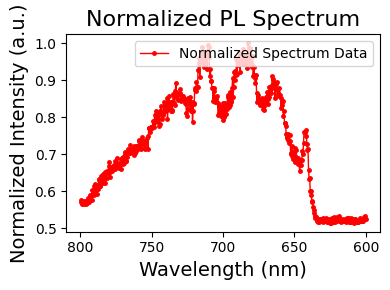

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 파일 경로 설정 (경로 오류 방지를 위해 r string 사용)
base_path = r"C:\Users\oprs1\Measurement\spectrometer\LT_2_ensemble_ZPLPSB.csv"

try:
    # 데이터 읽기
    df = pd.read_csv(base_path, header=None, names=['Wavelength', 'Count'])
    
    # -----------------------------------------------------------
    # [데이터 필터링]
    # 문법 수정: & 연산자 사용 시 조건별 괄호 () 필수
    # -----------------------------------------------------------
    df_filtered = df[(df['Wavelength'] <= 800) & (df['Wavelength'] >= 600)].copy()

    # 데이터 유무 확인
    if df_filtered.empty:
        print("설정된 파장 범위(400~750nm) 내에 데이터가 없습니다.")
    else:
        # -----------------------------------------------------------
        # [핵심 변경] Y축 상대값(Relative Value) 변환
        # 최대값으로 나누어 0 ~ 1 사이의 값으로 만듭니다.
        # -----------------------------------------------------------
        max_val = df_filtered['Count'].max()
        df_filtered['Relative_Count'] = df_filtered['Count'] / max_val

        # 2. 그래프 그리기
        plt.figure(figsize=(4, 3))

        # Peak 관련 표시(점, 텍스트)는 모두 삭제하고 순수 데이터만 그립니다.
        plt.plot(df_filtered['Wavelength'], df_filtered['Relative_Count'], 
                 label='Normalized Spectrum Data', color='red', linewidth=1, marker='.', markersize=5)

        # 3. 스타일 설정
        plt.title('Normalized PL Spectrum', fontsize=16)
        plt.xlabel('Wavelength (nm)', fontsize=14)
        
        # Y축 라벨 변경 (Count -> Normalized Intensity)
        plt.ylabel('Normalized Intensity (a.u.)', fontsize=14) 
        
        #plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(loc='upper right')

        # X축 반전
        plt.gca().invert_xaxis()

        # X축 숫자(라벨) 숨기기
        # plt.gca().set_xticklabels([])

        plt.tight_layout()
        
        # 4. 저장 및 출력 (저장을 먼저 해야 함)
        save_filename = 'graph_output_relative.png'
        plt.savefig(save_filename, dpi=300)
        print(f"그래프가 '{save_filename}'로 저장되었습니다.")

        plt.show()

except FileNotFoundError:
    print(f"오류: 파일을 찾을 수 없습니다.\n경로: {base_path}")
except Exception as e:
    print(f"오류 발생: {e}")

## Spectral diffusion

In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# 6번 셀과 동일한 폴더 경로
folder_path = r"C:\Users\oprs1\Measurement\PLE\20250326\temp_CRcheck_2\*.csv"
files = glob.glob(folder_path)

max_values = []
for filepath in files:
    df = pd.read_csv(filepath)
    if 'count' in df.columns and not df['count'].empty:
        max_values.append(df['count'].max())

max_values = np.array(max_values, dtype=float)

if len(max_values) < 2:
    print("최대값 분포 피팅을 하기 위한 데이터가 부족합니다. (최소 2개 필요)")
else:
    mu, sigma = norm.fit(max_values)

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # (1) 분포 + 정규분포 피팅
    counts, bins, _ = axes[0].hist(max_values, bins='auto', alpha=0.6, color='steelblue', edgecolor='black')
    x_fit = np.linspace(bins[0], bins[-1], 300)
    bin_width = bins[1] - bins[0] if len(bins) > 1 else 1.0
    y_fit = norm.pdf(x_fit, mu, sigma) * len(max_values) * bin_width
    axes[0].plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit: μ={mu:.2f}, σ={sigma:.2f}')
    axes[0].set_title('Distribution of Max Count')
    axes[0].set_xlabel('Max Count')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # (2) 각 최대값 + 선형 피팅
    file_index = np.arange(1, len(max_values) + 1)
    fit_coeff = np.polyfit(file_index, max_values, 1)
    fit_line = np.polyval(fit_coeff, file_index)
    axes[1].plot(file_index, max_values, 'ko', markersize=4, label='Max values')
    axes[1].plot(file_index, fit_line, 'r--', linewidth=1.5, label='Linear fit')
    axes[1].set_title('Max Value per File')
    axes[1].set_xlabel('File Index')
    axes[1].set_ylabel('Max Count')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

['C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_18시54분52초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_18시57분31초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시00분10초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시02분49초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시05분27초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시08분06초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시10분45초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시13분25초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시16분04초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시18분43초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시21분25초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시24분07초.csv', 'C:

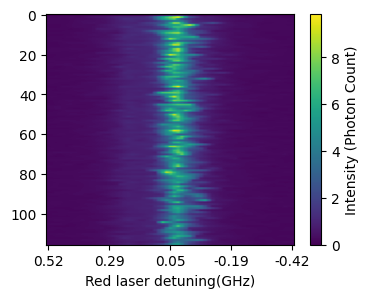

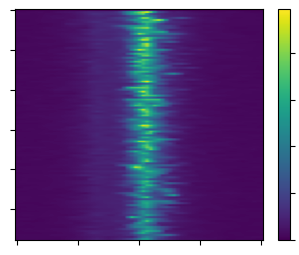

In [ ]:
import glob
import pandas as pd
import numpy as np

folder_path = "C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\*.csv"  # 모든 파일 검색
files = glob.glob(folder_path)
print(files)
x_left = 637.20912
x_right = 637.2104
x_fixed = np.arange(x_left, x_right, 0.00002)
intergrated_array = np.zeros(np.shape(x_fixed)[0])
intergrated_array.reshape(-1, 1)
for file in files:
    df = pd.read_csv(file)
    if df['count'].max() > 2:
        y_interpolated = np.interp(x_fixed, df['Wavelength'], df['count'])
        intergrated_array = np.vstack([intergrated_array, y_interpolated])
fig, ax = plt.subplots(figsize=(4, 3))
cax = ax.imshow(intergrated_array, aspect='auto', cmap='viridis')

# Adding x ticks from 637.20912 to 637.2104
x_ticks = np.linspace(x_left, x_right, 5)

# 파장을 주파수로 변환하고 470.4 THz로부터의 detuning 계산
c_nm_per_s = 299792.458  # 빛의 속도 (nm/s 단위의 GHz)
freq_ticks = c_nm_per_s / x_ticks  # THz 단위
detuning_ghz = (freq_ticks - 470.47682747) * 1000  # GHz 단위로 변환

cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Intensity (Photon Count)")
# ax.set_title("Spectral diffusion")
ax.set_xticks(np.linspace(0, intergrated_array.shape[1] - 1, 5))
ax.set_xticklabels([f'{detune:.2f}' for detune in detuning_ghz])
ax.set_xlabel('Red laser detuning(GHz)')
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\spectral_with_labels.svg', format='svg', bbox_inches='tight')
plt.show()

# 라벨과 텍스트가 없는 깔끔한 그래프
fig, ax = plt.subplots(figsize=(4, 3))
cax = ax.imshow(intergrated_array, aspect='auto', cmap='viridis')
cbar = fig.colorbar(cax, ax=ax)
ax.set_xticks(np.linspace(0, intergrated_array.shape[1] - 1, 5), ['']*5)  # X축 눈금은 유지하되 라벨은 제거
ax.set_yticks([0, 20, 40, 60, 80, 100], ['']*6)  # Y축 눈금은 유지하되 라벨은 제거
cbar.ax.set_yticklabels([])
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\spectral_no_labels.svg', format='svg', bbox_inches='tight')
plt.show()


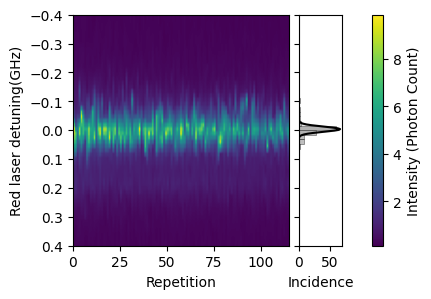

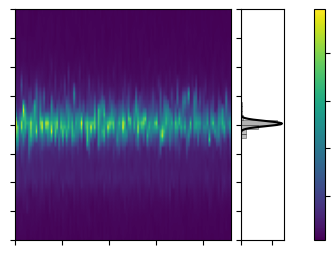

In [259]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit

folder_path = "C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\*.csv"
files = glob.glob(folder_path)

x_left = 637.20912
x_right = 637.2104
x_fixed = np.arange(x_left, x_right, 0.00002)

# 1. 데이터 로드 및 전처리
intergrated_array = np.zeros(np.shape(x_fixed)[0])
for file in files:
    df = pd.read_csv(file)
    if df['count'].max() > 2:
        y_interpolated = np.interp(x_fixed, df['Wavelength'], df['count'])
        intergrated_array = np.vstack([intergrated_array, y_interpolated])

intergrated_array = intergrated_array[1:]
rotated_array = intergrated_array.T
num_scans = rotated_array.shape[1]

# 2. 초기 Detuning 계산
c_nm_per_s = 299792.458
freq_fixed = c_nm_per_s / x_fixed
detuning_raw = (freq_fixed - 470.47682747) * 1000

# 3. 피크가 가장 많이 몰린 지점을 0으로 설정 (Zero-centering)
peak_indices = np.argmax(rotated_array, axis=0)
peak_locations_raw = detuning_raw[peak_indices]
center_frequency = np.mean(peak_locations_raw)

# 전체 축을 중심점만큼 이동
detuning_all = detuning_raw - center_frequency
peak_detunings = detuning_all[peak_indices]

# 4. 오른쪽 분포 및 피팅 데이터 계산
bins_range = np.linspace(-0.4, 0.4, 51)
counts, bin_edges = np.histogram(peak_detunings, bins=bins_range)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_height = bin_edges[1] - bin_edges[0]

# 정규분포(Gaussian) 함수 정의
def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))

# 피팅 진행
guess = [np.max(counts), 0, np.std(peak_detunings)]

try:
    popt, _ = curve_fit(gaussian, bin_centers, counts, p0=guess)
except:
    popt = guess

# 피팅 파라미터 조정
width_multiplier = 1
fitted_stddev_relaxed = popt[2] * width_multiplier

# 부드러운 피팅 곡선을 그리기 위해 촘촘한 Y축(Detuning) 배열 생성
y_fit_smooth = np.linspace(0.4, -0.4, 300)

# 수정된 넓은 표준편차를 사용하여 피팅 곡선 X축(Occurrences) 계산
x_fit_smooth_relaxed = gaussian(y_fit_smooth, popt[0], popt[1], fitted_stddev_relaxed)

# ==========================================
# 5. 그래프 그리기 - 라벨 있는 버전
# ==========================================
fig, ax_main = plt.subplots(figsize=(4, 3))

extent = [0, num_scans, detuning_all[-1], detuning_all[0]]
im = ax_main.imshow(rotated_array, aspect='auto', extent=extent, cmap='viridis', origin='upper')

ax_main.set_ylim(0.4, -0.4)
ax_main.set_xlabel('Repetition')
ax_main.set_ylabel('Red laser detuning(GHz)')

divider = make_axes_locatable(ax_main)
ax_right = divider.append_axes("right", size="20%", pad=0.1)

ax_right.barh(bin_centers, counts, height=bar_height, color='gray', alpha=0.5, edgecolor='black', linewidth=0.5, label='Distribution')
ax_right.plot(x_fit_smooth_relaxed, y_fit_smooth, color='black', linewidth=1.5, label='Fit')
ax_right.fill_betweenx(y_fit_smooth, 0, x_fit_smooth_relaxed, color='gray', alpha=0.2)

ax_right.set_ylim(0.4, -0.4)
ax_right.set_xlabel('Incidence')
ax_right.tick_params(labelleft=False)

cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Intensity (Photon Count)")

plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\spectral_horizontal_bar_fit_relaxed.svg', format='svg', bbox_inches='tight')
plt.show()

# ==========================================
# 6. 그래프 그리기 - 라벨 없는 버전
# ==========================================
fig, ax_main = plt.subplots(figsize=(4, 3))

im = ax_main.imshow(rotated_array, aspect='auto', extent=extent, cmap='viridis', origin='upper')
ax_main.set_ylim(0.4, -0.4)

divider = make_axes_locatable(ax_main)
ax_right = divider.append_axes("right", size="20%", pad=0.1)

ax_right.barh(bin_centers, counts, height=bar_height, color='gray', alpha=0.5, edgecolor='black', linewidth=0.5)
ax_right.plot(x_fit_smooth_relaxed, y_fit_smooth, color='black', linewidth=1.5)
ax_right.fill_betweenx(y_fit_smooth, 0, x_fit_smooth_relaxed, color='gray', alpha=0.2)
ax_right.set_ylim(0.4, -0.4)

# 메인축/우측축/컬러바 모두 라벨 제거
ax_main.tick_params(labelbottom=False, labelleft=False)
ax_right.tick_params(labelbottom=False, labelleft=False)

cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelleft=False, labelright=False)

plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\spectral_horizontal_bar_fit_relaxed_nolabel.svg', format='svg', bbox_inches='tight')
plt.show()

['C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_18시54분52초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_18시57분31초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시00분10초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시02분49초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시05분27초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시08분06초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시10분45초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시13분25초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시16분04초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시18분43초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시21분25초.csv', 'C:\\Users\\oprs1\\Measurement\\PLE\\20250326\\temp_CRcheck_2\\PLE_19시24분07초.csv', 'C:

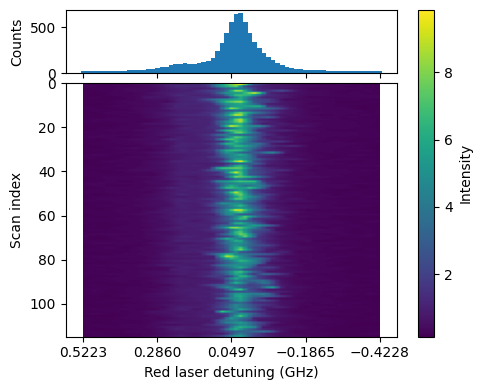

In [16]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ----------------------------
# load files
# ----------------------------

folder_path = r"C:\Users\oprs1\Measurement\PLE\20250326\temp_CRcheck_2\*.csv"

files = glob.glob(folder_path)

print(files)

# ----------------------------
# wavelength range
# ----------------------------

x_left = 637.20912
x_right = 637.2104

x_fixed = np.arange(
    x_left,
    x_right,
    0.00002
)

# ----------------------------
# interpolation
# ----------------------------

intergrated_array = []

for file in files:

    df = pd.read_csv(file)

    if df['count'].max() > 2:

        y_interpolated = np.interp(
            x_fixed,
            df['Wavelength'],
            df['count']
        )

        intergrated_array.append(y_interpolated)

intergrated_array = np.array(intergrated_array)

# ----------------------------
# integrated distribution
# ----------------------------

distribution = np.sum(
    intergrated_array,
    axis=0
)

# ----------------------------
# wavelength -> detuning
# ----------------------------

c_nm_per_ps = 299792.458

freq_axis = c_nm_per_ps / x_fixed

detuning_ghz = (
    freq_axis - 470.47682747
) * 1000

# ----------------------------
# statistics
# ----------------------------

mean_wavelength = np.sum(
    x_fixed * distribution
) / np.sum(distribution)

variance = np.sum(
    distribution *
    (x_fixed - mean_wavelength)**2
) / np.sum(distribution)

std_dev = np.sqrt(variance)

print(f"Mean wavelength : {mean_wavelength:.6f} nm")
print(f"Variance         : {variance * 1e6:.3f} pm²")
print(f"Std deviation    : {std_dev * 1e3:.3f} pm")

# ----------------------------
# plot
# ----------------------------

fig, ax = plt.subplots(
    figsize=(5, 4)
)

divider = make_axes_locatable(ax)

ax_top = divider.append_axes(
    "top",
    size="25%",
    pad=0.1,
    sharex=ax
)

# waterfall map
cax = ax.imshow(
    intergrated_array,
    aspect='auto',
    cmap='viridis',
    extent=[
        detuning_ghz[0],
        detuning_ghz[-1],
        intergrated_array.shape[0],
        0
    ]
)

# histogram
ax_top.bar(
    detuning_ghz,
    distribution,
    width=np.abs(
        detuning_ghz[1] - detuning_ghz[0]
    ),
    align='center'
)

# histogram style
ax_top.set_ylabel("Counts")


plt.setp(
    ax_top.get_xticklabels(),
    visible=False
)

# axis labels
ax.set_xlabel(
    'Red laser detuning (GHz)'
)

ax.set_ylabel(
    'Scan index'
)

ax.set_xticks(
    np.linspace(
        detuning_ghz[0],
        detuning_ghz[-1],
        5
    )
)

# colorbar
cbar = fig.colorbar(
    cax,
    ax=ax
)

cbar.set_label(
    "Intensity"
)

plt.tight_layout()

plt.show()

## Entangle state

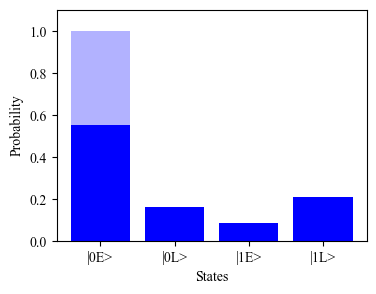

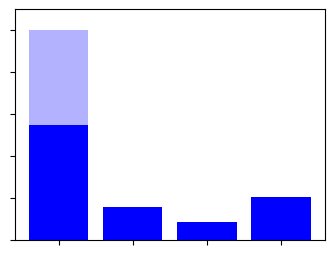

In [191]:
import matplotlib.pyplot as plt

# 데이터
labels = ['|0E>', '|0L>', '|1E>', '|1L>']
values = [135, 39, 21, 51]
expectation_value = sum(values)
values = np.array(values) / expectation_value

# expectation value 계산
expectation_value = sum(values)

# 막대 그래프 생성 (라벨 있는 버전)
plt.figure(figsize=(4, 3))
plt.bar(labels, values, color = 'blue', alpha=1)
plt.bar(labels[0], expectation_value, color='blue', alpha=0.3)
plt.xlabel('States')
plt.ylim(0, 1.1)
plt.ylabel('Probability')
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\bar_cell24_with_labels.svg', format='svg', bbox_inches='tight')
plt.show()

# 막대 그래프 생성 (라벨 없는 버전)
plt.figure(figsize=(4, 3))
plt.bar(labels, values, color = 'blue', alpha=1)
plt.bar(labels[0], expectation_value, color='blue', alpha=0.3)
plt.tick_params(labelbottom=False, labelleft=False)
plt.ylim(0, 1.1)
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\bar_cell24_no_labels.svg', format='svg', bbox_inches='tight')

plt.show()

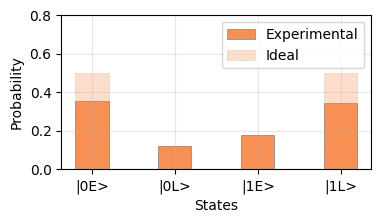

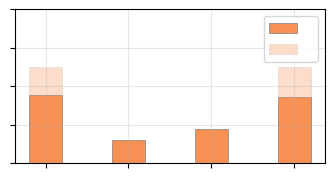

In [251]:
import matplotlib.pyplot as plt

# 데이터
labels = ['|0E>', '|0L>', '|1E>', '|1L>']
values = [202, 68, 101, 196]

# expectation value 계산
expectation_value = sum(values)

values = np.array(values) / expectation_value

# 막대 그래프 생성 (라벨 있는 버전)
plt.figure(figsize=(4, 2))
plt.bar(labels, values, color = '#F79153', alpha=1, width = 0.4, edgecolor='grey', linewidth=0.5)
plt.bar(labels, [1/2, 0, 0, 1/2], color='#F79153', alpha=0.3, width = 0.4, edgecolor='grey', linewidth=0.5, linestyle='--')
plt.legend(['Experimental', 'Ideal'], loc='upper right')
plt.xlabel('States')
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.8)
plt.ylabel('Probability')
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\bar_cell25_with_labels.svg', format='svg', bbox_inches='tight')
plt.show()

# 막대 그래프 생성 (라벨 없는 버전)
plt.figure(figsize=(4, 2))
plt.bar(labels, values, color = '#F79153', alpha=1, width = 0.4, edgecolor='grey', linewidth=0.5)
plt.ylim(0, 0.8)
plt.grid(True, alpha=0.3)
plt.bar(labels, [1/2, 0, 0, 1/2], color='#F79153', alpha=0.3, width = 0.4, edgecolor='grey', linewidth=0.5, linestyle='--')
plt.tick_params(labelbottom=False, labelleft=False)
plt.legend([' ', ' '], loc='upper right')

plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\bar_cell25_no_labels.svg', format='svg', bbox_inches='tight')
plt.show()

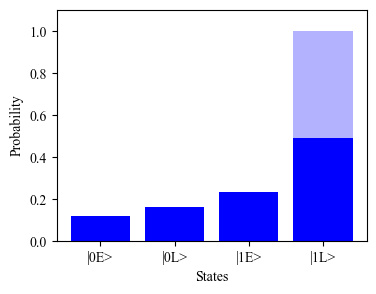

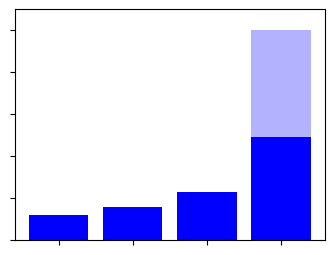

In [193]:
import matplotlib.pyplot as plt

# 데이터
labels = ['|0E>', '|0L>', '|1E>', '|1L>']
values = [0.12, 0.16, 0.23, 0.49]

# expectation value 계산
expectation_value = sum(values)

values = np.array(values) / expectation_value

# 막대 그래프 생성 (라벨 있는 버전)
plt.figure(figsize=(4, 3))
plt.bar(labels, values, color = 'blue', alpha=1)
plt.bar(labels, [0, 0, 0, 1], color='blue', alpha=0.3)
plt.xlabel('States')
plt.ylim(0, 1.1)
plt.ylabel('Probability')
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\bar_cell26_with_labels.svg', format='svg', bbox_inches='tight')
plt.show()

# 막대 그래프 생성 (라벨 없는 버전)
plt.figure(figsize=(4, 3))
plt.ylim(0, 1.1)
plt.bar(labels, values, color = 'blue', alpha=1)
plt.bar(labels, [0, 0, 0, 1], color='blue', alpha=0.3)
plt.tick_params(labelbottom=False, labelleft=False)

plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\bar_cell26_no_labels.svg', format='svg', bbox_inches='tight')
plt.show()

## ODMR

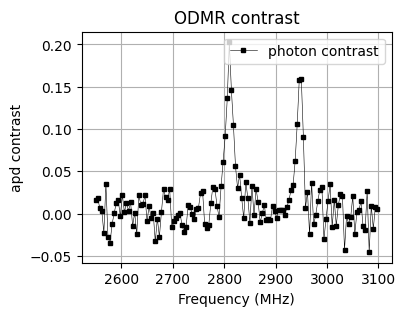

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 파일 경로
filename = 'C:\\Users\\oprs1\\Measurement\\ODMR\\20260318\\ODMR_13시23분30초.csv'

# CSV 파일 읽기
df = pd.read_csv(filename)

# x, y 데이터
x = df['Unnamed: 0']
y = df['apd_contrast']

# Gaussian 함수 정의
def gauss(x, a, x0, sigma, c):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + c

# 초기 추정값 (a, x0, sigma, c)
p0 = [y.max() - y.min(), x.iloc[y.argmin()], (x.max()-x.min())/10, y.min()]

# curve_fit으로 피팅
popt, pcov = curve_fit(gauss, x, y, p0=p0)

# 피팅 결과 곡선
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = gauss(x_fit, *popt)

# plot
plt.figure(figsize=(4, 3))
plt.plot(x, y, 'ks-', label='photon contrast', linewidth=0.4, markersize = 3)
# plt.plot(x_fit, y_fit, 'r-', label='', linewidth=0.4)
plt.xlabel('Frequency (MHz)')
plt.ylabel('apd contrast')
plt.title('ODMR contrast')
plt.legend(loc = 'upper right')
plt.grid(True)
# plt.show()

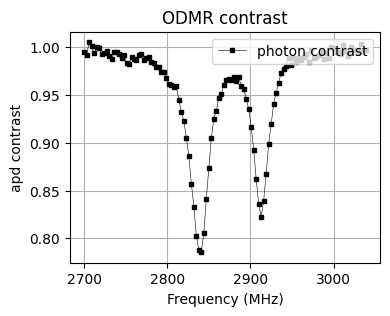

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 파일 경로
filename = 'C:\\Users\\oprs1\\Measurement\\ODMR\\20250207\\ODMR_14시26분42초.csv'

# CSV 파일 읽기
df = pd.read_csv(filename)

# x, y 데이터
x = df['Unnamed: 0']
y = 1-(df['i_apd1_sum'] - df['i_apd0_sum']) / df['i_apd1_sum']

# Gaussian 함수 정의
def gauss(x, a, x0, sigma, c):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + c

# 초기 추정값 (a, x0, sigma, c)
p0 = [y.max() - y.min(), x.iloc[y.argmin()], (x.max()-x.min())/10, y.min()]

# curve_fit으로 피팅
popt, pcov = curve_fit(gauss, x, y, p0=p0)

# 피팅 결과 곡선
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = gauss(x_fit, *popt)

# plot
plt.figure(figsize=(4, 3))
plt.plot(x, y, 'ks-', label='photon contrast', linewidth=0.4, markersize = 3)
# plt.plot(x_fit, y_fit, 'r-', label='', linewidth=0.4)
plt.xlabel('Frequency (MHz)')
plt.ylabel('apd contrast')
plt.title('ODMR contrast')
plt.legend(loc = 'upper right')
plt.grid(True)
# plt.show()

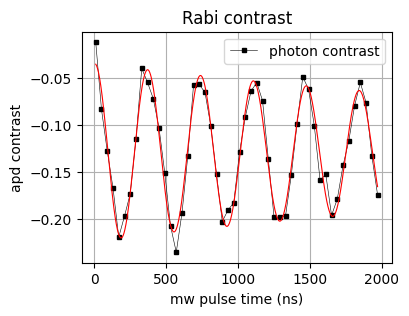

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 파일 경로
filename = 'C:\\Users\\oprs1\\Measurement\\rabi_gg_PSB\\20251009\\rabi_gg_PSB_17시19분19초.csv'

# 데이터 읽기
df = pd.read_csv(filename)
x = df['Unnamed: 0']
y = -1*df['apd_contrast']

# damped sine 함수 정의
def damped_sine(x, A, gamma, omega, phi, offset):
    return A * np.exp(-gamma * x) * np.sin(omega * x + phi) + offset

# 초기 추정값 (A, gamma, omega, phi, offset)
A0 = (y.max() - y.min()) / 2
gamma0 = 0.001
omega0 = 2 * np.pi / (x.max() - x.min())
phi0 = 0
offset0 = y.mean()
p0 = [A0, gamma0, omega0, phi0, offset0]

# curve_fit
popt, pcov = curve_fit(damped_sine, x, y, p0=p0, maxfev=10000)

# 피팅 결과
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = damped_sine(x_fit, *popt)

# plot
plt.figure(figsize=(4, 3))
plt.plot(x, y, 'ks-', label='photon contrast', linewidth=0.4, markersize = 3)
plt.plot(x_fit, y_fit, 'r-', label='', linewidth=0.8)
plt.xlabel('mw pulse time (ns)')
plt.ylabel('apd contrast')
plt.title('Rabi contrast')
plt.legend()
plt.grid(True)
plt.show()

## Confocal

Index(['17.1', '16.0', '18.3', '18.4', '20.1', '19.0', '20.4', '20.0', '19.8',
       '20.2', '18.2', '22.1', '18.6', '21.3', '20.1.1', '18.0', '20.1.2',
       '21.0', '22.0', '20.5', '20.2.1', '24.1', '22.3', '21.6', '22.6',
       '24.0', '22.7', '21.0.1', '21.9', '25.1', '26.0', '21.9.1', '24.0.1',
       '22.6.1', '20.5.1', '22.0.1', '20.9', '22.1.1', '18.7', '22.8',
       '22.0.2', '21.4', '20.9.1', '21.3.1', '21.1', '18.0.1', '15.6', '19.4',
       '16.9', '19.0.1', '18.8'],
      dtype='object')


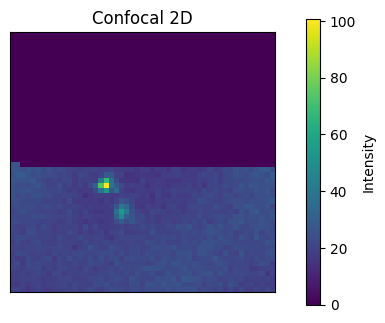

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# 파일 경로
filename = r'C:\\Users\\oprs1\\Measurement\\Confocal\\20260329\\20시19분32초, z=57.0000765.csv'

# CSV 파일 읽기
data = pd.read_csv(filename)

# 키 확인 (데이터 구조에 따라 다를 수 있음)
print(data.columns)

# 예시: 'image'라는 key에 2D 이미지 데이터가 있다고 가정
# 실제 key는 print(data.columns) 결과를 보고 맞게 수정
img = data

plt.figure(figsize=(4, 4))
plt.imshow(img, origin='lower')
plt.colorbar(label='Intensity',fraction = 0.046, pad = 0.1)
plt.title('Confocal 2D')
plt.xticks([])
plt.yticks([])
plt.show()

## PLE

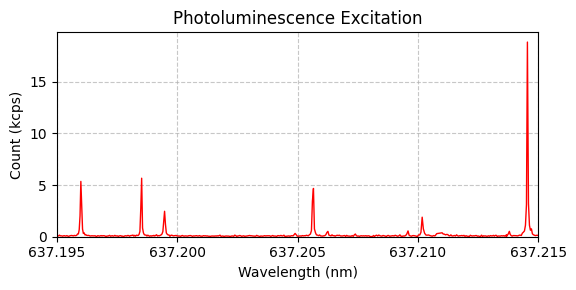

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

filename = r"C:\Users\oprs1\Measurement\PLE\20260423\PLE_15시25분33초.csv"

df = pd.read_csv(filename)

x = df["Wavelength"]
y = df["count"]

plt.figure(figsize=(6, 3))
plt.plot(x, y, color="red", linewidth=1)

plt.title("Photoluminescence Excitation")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Count (kcps)")

plt.xlim(637.195, 637.215)
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.7)

plt.ticklabel_format(useOffset=False, style="plain", axis="x")
plt.locator_params(axis="x", nbins=5)

plt.tight_layout()
plt.show()

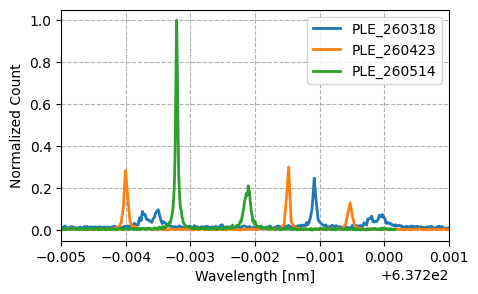

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file1 = r"C:\Users\oprs1\Measurement\PLE\20260318\PLE_10시50분18초.csv"
file2 = r"C:\Users\oprs1\Measurement\PLE\20260423\PLE_15시25분33초.csv"
file3 = r"C:\Users\oprs1\Measurement\PLE\20260514\PLE_20시27분37초.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)


df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()

w1 = pd.to_numeric(df1["Wavelength"], errors='coerce')
c1 = pd.to_numeric(df1["count"], errors='coerce')

w2 = pd.to_numeric(df2["Wavelength"], errors='coerce')
c2 = pd.to_numeric(df2["count"], errors='coerce')

w3 = pd.to_numeric(df3["Wavelength"], errors='coerce')
c3 = pd.to_numeric(df3["count"], errors='coerce')

c1 = c1 / np.max(c1)
c2 = c2 / np.max(c2)
c3 = c3 / np.max(c3)

plt.figure(figsize=(5,3))
plt.plot(w1, c1, label='PLE_260318', linewidth = 2)
plt.plot(w2, c2, label='PLE_260423', linewidth = 2)
plt.plot(w3, c3, label='PLE_260514', linewidth = 2)

plt.xlim(637.195, 637.201)
# plt.xlim(637.2135, 637.216)

plt.xlabel("Wavelength [nm]")
plt.ylabel("Normalized Count")
plt.grid(True, linestyle='--')
plt.legend()

plt.show()

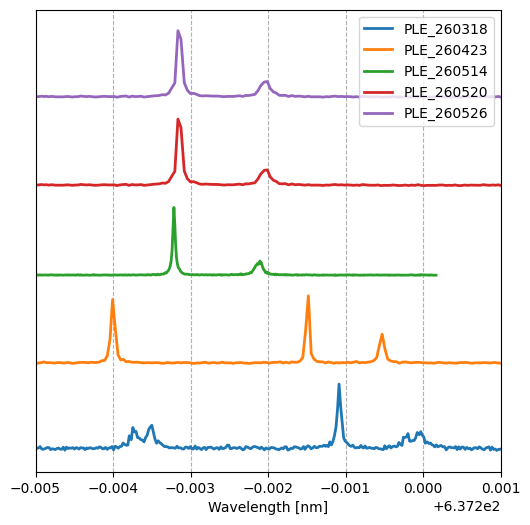

In [42]:
# PLE peak shifting 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file1 = r"C:\Users\oprs1\Measurement\PLE\20260318\PLE_10시50분18초.csv"
file2 = r"C:\Users\oprs1\Measurement\PLE\20260423\PLE_15시25분33초.csv"
file3 = r"C:\Users\oprs1\Measurement\PLE\20260514\PLE_20시27분37초.csv"
file4 = r"C:\Users\oprs1\Measurement\PLE\20260520\PLE_18시42분45초.csv"
file5 = r"C:\Users\oprs1\Measurement\PLE\20260526\PLE_19시35분45초.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)
df4 = pd.read_csv(file4)
df5 = pd.read_csv(file5)


df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
df3.columns = df3.columns.str.strip()
df4.columns = df4.columns.str.strip()
df5.columns = df5.columns.str.strip()

w1 = pd.to_numeric(df1["Wavelength"], errors='coerce')
c1 = pd.to_numeric(df1["count"], errors='coerce')
w2 = pd.to_numeric(df2["Wavelength"], errors='coerce')
c2 = pd.to_numeric(df2["count"], errors='coerce')
w3 = pd.to_numeric(df3["Wavelength"], errors='coerce')
c3 = pd.to_numeric(df3["count"], errors='coerce')
w4 = pd.to_numeric(df4["Wavelength"], errors='coerce')
c4 = pd.to_numeric(df4["count"], errors='coerce')
w5 = pd.to_numeric(df4["Wavelength"], errors='coerce')
c5 = pd.to_numeric(df4["count"], errors='coerce')

# 637.201 nm 이하 영역만 사용해서 normalization
norm_max1 = np.max(c1[w1 <= 637.201])
norm_max2 = np.max(c2[w2 <= 637.201])
norm_max3 = np.max(c3[w3 <= 637.201])
norm_max4 = np.max(c4[w4 <= 637.201])
norm_max5 = np.max(c5[w5 <= 637.201])


c1 = c1 / norm_max1
c2 = c2 / norm_max2
c3 = c3 / norm_max3
c4 = c4 / norm_max4
c5 = c5 / norm_max5

# 세로 offset
offset1 = 0.0
offset2 = 1.3
offset3 = 2.6
offset4 = 3.9
offset5 = 5.2


plt.figure(figsize=(6, 6))

plt.plot(w1, c1 + offset1, label='PLE_260318', linewidth=2)
plt.plot(w2, c2 + offset2, label='PLE_260423', linewidth=2)
plt.plot(w3, c3 + offset3, label='PLE_260514', linewidth=2)
plt.plot(w4, c4 + offset4, label='PLE_260520', linewidth=2)
plt.plot(w5, c5 + offset5, label='PLE_260526', linewidth=2)

plt.xlim(637.195, 637.201)
plt.xlabel("Wavelength [nm]")
plt.yticks([])
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

Peak center = 637.198508295 nm
Linewidth = 0.000027348 nm
Linewidth = 20.19 MHz


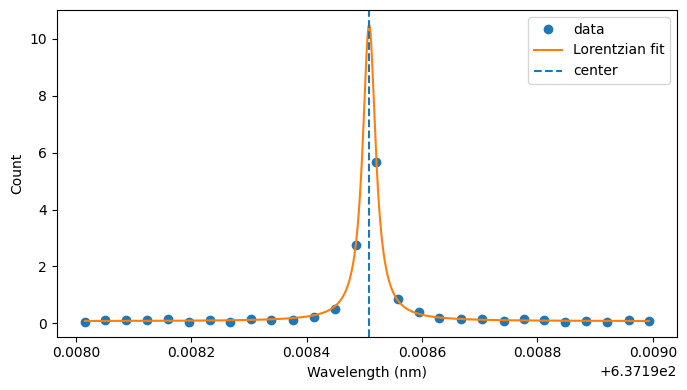

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

filename = r"C:\Users\oprs1\Measurement\PLE\20260423\PLE_15시25분33초.csv"

df = pd.read_csv(filename)

x = df["Wavelength"].values
y = df["count"].values

# 원하는 피크 범위 지정
wl_min = 637.198
wl_max = 637.199

mask = (x >= wl_min) & (x <= wl_max)
xf = x[mask]
yf = y[mask]

def lorentzian(x, y0, A, x0, gamma):
    return y0 + A * (0.5 * gamma)**2 / ((x - x0)**2 + (0.5 * gamma)**2)

# 초기값
y0_guess = np.min(yf)
A_guess = np.max(yf) - np.min(yf)
x0_guess = xf[np.argmax(yf)]
gamma_guess = (wl_max - wl_min) / 10

p0 = [y0_guess, A_guess, x0_guess, gamma_guess]

popt, pcov = curve_fit(lorentzian, xf, yf, p0=p0)

y0, A, x0, fwhm_nm = popt

# nm -> MHz 변환
c = 299792458  # m/s

lambda_m = x0 * 1e-9          # 중심파장 (m)
delta_lambda = fwhm_nm * 1e-9 # linewidth (m)

linewidth_Hz = c * delta_lambda / lambda_m**2
linewidth_MHz = linewidth_Hz / 1e6

print(f"Peak center = {x0:.9f} nm")
print(f"Linewidth = {fwhm_nm:.9f} nm")
print(f"Linewidth = {linewidth_MHz:.2f} MHz")

xfit = np.linspace(xf.min(), xf.max(), 1000)
yfit = lorentzian(xfit, *popt)

plt.figure(figsize=(7, 4))
plt.plot(xf, yf, "o", label="data")
plt.plot(xfit, yfit, "-", label="Lorentzian fit")
plt.axvline(x0, linestyle="--", label="center")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

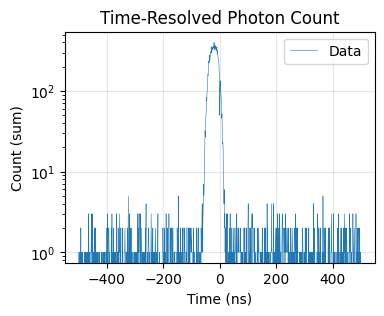

In [85]:
# 최종 고해상도 버전 (출판/발표용)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 파일 경로
filename = r'C:\\Users\\oprs1\\Measurement\\Time Tagger\\260421\\no coating bulk min reflect_2.txt'

# 첫 줄(헤더)을 제외하고 데이터 읽기
data = np.loadtxt(filename, skiprows=1)

# 첫 번째 열: time, 두 번째 열: count
time = data[:, 0]/1000
count = data[:, 1]
plt.figure(figsize=(4, 3))
plt.plot(time, count, '-', label='Data', linewidth=0.4, markersize=3)
plt.xlabel('Time (ns)')
plt.ylabel('Count (sum)')
plt.title('Time-Resolved Photon Count')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Y축 선형 스케일로 설정

## G2

Fitting parameters:
y0 = 38.0681
x0 = 362.5887
a = -0.4006
tau1 = 15656.3740
tau2 = 318.5393

Model fitting 최대값: 29.5153
count_fit[0] (tau=0 근처): 29.5153
최대값 / count_fit[0] = 1.0000
피팅 에러: [Errno 2] No such file or directory: 'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\g2_with_labels_linear.svg'
초기값을 조정하거나 데이터를 확인하세요.


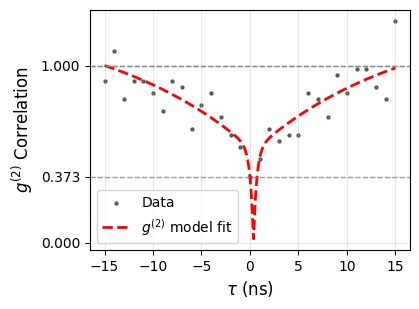

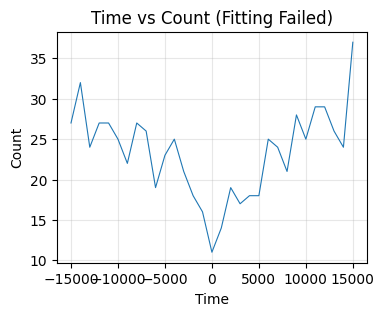

In [95]:
# 최종 고해상도 버전 (출판/발표용)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 파일 경로
filename = r"C:\Users\oprs1\Measurement\Time Tagger\HOM\2026-07-08_093145 - 532 cw HOM (13h).txt"

# 첫 줄(헤더)을 제외하고 데이터 읽기
data = np.loadtxt(filename, skiprows=1)

# 첫 번째 열: time, 두 번째 열: count
time = data[:, 0]
count = data[:, 1]

# 실제 데이터 범위 조건(-200 ~ 200 ns)
time_ns = time / 1000
mask = (time_ns >= -15) & (time_ns <= 15)
time_filtered = time[mask]
count_filtered = count[mask]

if len(time_filtered) == 0:
    raise ValueError("-200~200 ns 범위에 해당하는 데이터가 없습니다.")

# g2 모델 함수 정의
def g2_model(x, y0, x0, a, tau1, tau2):
    return y0 * (1 - (1 + a) * np.exp(-np.abs(x - x0) / tau1) + a * np.exp(-np.abs(x - x0) / tau2))

# 초기 추정값 설정
y0_init = count_filtered.mean()
x0_init = time_filtered[count_filtered.argmin()]
a_init = 0.5
time_range = time_filtered.max() - time_filtered.min()
tau1_init = time_range / 10
tau2_init = time_range / 5

p0 = [y0_init, x0_init, a_init, tau1_init, tau2_init]

try:
    # curve_fit으로 피팅
    popt, pcov = curve_fit(g2_model, time_filtered, count_filtered, p0=p0, maxfev=10000)

    # 피팅 결과 출력
    print("Fitting parameters:")
    print(f"y0 = {popt[0]:.4f}")
    print(f"x0 = {popt[1]:.4f}")
    print(f"a = {popt[2]:.4f}")
    print(f"tau1 = {popt[3]:.4f}")
    print(f"tau2 = {popt[4]:.4f}")

    # 피팅 곡선 생성
    time_fit = np.linspace(time_filtered.min(), time_filtered.max(), 1000)
    count_fit = g2_model(time_fit, *popt)

    print(f"\nModel fitting 최대값: {count_fit.max():.4f}")
    print(f"count_fit[0] (tau=0 근처): {count_fit[0]:.4f}")
    print(f"최대값 / count_fit[0] = {count_fit.max() / count_fit[0]:.4f}")

    # 정규화: 피팅 곡선의 최대값을 1로
    count_fit_normalized = count_fit / count_fit.max()
    max_value_normalized = count_fit.max() / count_fit[0]

    # --- Labeled: Linear scale ---
    fig, ax = plt.subplots(figsize=(4, 3))
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
    ax.scatter(time_filtered / 1000, count_filtered / count_fit[0], s=5, alpha=0.5, label='Data', color='black')
    ax.plot(time_fit / 1000, count_fit / count_fit[0], 'r--', linewidth=2, label='$g^{(2)}$ model fit')
    ax.axhline(y=max_value_normalized, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y=1, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y=count_filtered.min()/count_fit[0], color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('$\\tau$ (ns)', fontsize=12)
    ax.set_ylabel('$g^{(2)}$ Correlation', fontsize=12)
    ax.set_yticks([0, count_filtered.min()/count_fit[0], 1])
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\g2_with_labels_linear.svg', format='svg')
    plt.show()

    # --- Labeled: Log scale ---
    fig, ax = plt.subplots(figsize=(4, 3))
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
    ax.scatter(time_filtered / 1000, count_filtered / count_fit[0], s=5, alpha=0.5, label='Data', color='black')
    ax.plot(time_fit / 1000, count_fit / count_fit[0], 'r--', linewidth=2, label='$g^{(2)}$ model fit')
    ax.set_yscale('log')
    ax.set_xlabel('$\\tau$ (ns)', fontsize=12)
    ax.set_ylabel('$g^{(2)}$ Correlation (log scale)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\g2_with_labels_log.svg', format='svg')
    plt.show()

    print(f"count_filterd 최소값: {count_filtered.min()/count_fit[0]:.4f}")

    # --- No-label: Linear scale ---
    fig, ax = plt.subplots(figsize=(4, 3))
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
    ax.scatter(time_filtered / 1000, count_filtered / count_fit[0], s=5, alpha=0.5, color='black')
    ax.plot(time_fit / 1000, count_fit / count_fit[0], 'r--', linewidth=2)
    ax.axhline(y=max_value_normalized, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y=1, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y = count_filtered.min()/count_fit[0], color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_yticks([0, 1])
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False, labelleft=False)
    fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\g2_no_labels_linear.svg', format='svg')
    plt.show()

    # --- No-label: Log scale ---
    fig, ax = plt.subplots(figsize=(4, 3))
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
    ax.scatter(time_filtered / 1000, count_filtered / count_fit[0], s=5, alpha=0.5, color='black')
    ax.plot(time_fit / 1000, count_fit / count_fit[0], 'r--', linewidth=2)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelbottom=False, labelleft=False)
    fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\g2_no_labels_log.svg', format='svg')
    plt.show()

except Exception as e:
    print(f"피팅 에러: {e}")
    print("초기값을 조정하거나 데이터를 확인하세요.")

    # 피팅 실패 시 원본 데이터만 플롯
    plt.figure(figsize=(4, 3))
    plt.plot(time_filtered, count_filtered, linewidth=0.8)
    plt.xlabel('Time')
    plt.ylabel('Count')
    plt.title('Time vs Count (Fitting Failed)')
    plt.grid(True, alpha=0.3)
    # plt.tight_layout()S
    plt.show()


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

filename = r"C:\Users\oprs1\Measurement\Time Tagger\HOM\2026-07-07_112540 - 532 cw HOM (2h30min).txt"

df = pd.read_csv(filename, sep="\t")
df.columns = df.columns.str.replace('"', '').str.strip()

time_ns = df["Time differences (ps)"].to_numpy() / 1000
count = df["Counts per bin"].to_numpy()

mask = (time_ns >= -50) & (time_ns <= 50)
x = time_ns[mask]
y = count[mask]

def g2_model(t, y0, x0, c, a, tau1, tau2):
    return y0 * (
        1
        - c * (
            (1 + a) * np.exp(-np.abs(t - x0) / tau1)
            - a * np.exp(-np.abs(t - x0) / tau2)
        )
    )

y0_init = np.mean(y[np.abs(x) > 30])
x0_init = x[np.argmin(y)]
c_init = 1 - y.min() / y0_init
a_init = 0.1
tau1_init = 5
tau2_init = 30

p0 = [y0_init, x0_init, c_init, a_init, tau1_init, tau2_init]

bounds = (
    [0,   -5,  0,  0,   0.1,  1],
    [np.inf, 5,  1,  5,   100,  500]
)

sigma = np.sqrt(np.maximum(y, 1))

popt, pcov = curve_fit(
    g2_model,
    x,
    y,
    p0=p0,
    bounds=bounds,
    sigma=sigma,
    absolute_sigma=True,
    maxfev=50000
)

y0, x0, c, a, tau1, tau2 = popt

xfit = np.linspace(x.min(), x.max(), 2000)
yfit = g2_model(xfit, *popt)

g2_data = y / y0
g2_fit = yfit / y0
g2_0 = 1 - c

print("Fitting parameters")
print(f"y0     = {y0:.4f}")
print(f"x0     = {x0:.4f} ns")
print(f"c      = {c:.4f}")
print(f"a      = {a:.4f}")
print(f"tau1   = {tau1:.4f} ns")
print(f"tau2   = {tau2:.4f} ns")
print(f"g2(0)  = {g2_0:.4f}")

plt.figure(figsize=(4.5, 3.5))

plt.scatter(x, g2_data, s=25, color="black", alpha=0.75, label="Data")
plt.plot(xfit, g2_fit, "r--", linewidth=2, label=r"$g^{(2)}$ fit")

plt.axhline(1, color="gray", linestyle="--", linewidth=1)
plt.axvline(x0, color="gray", linestyle=":", linewidth=1)

plt.xlabel(r"$\tau$ (ns)", fontsize=12)
plt.ylabel(r"$g^{(2)}(\tau)$", fontsize=12)

plt.xlim(-50, 50)
plt.ylim(0, 1.4)

plt.title("ZPL g2 Measurement", fontsize=12)
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ValueError: Initial guess is outside of provided bounds

## HOM

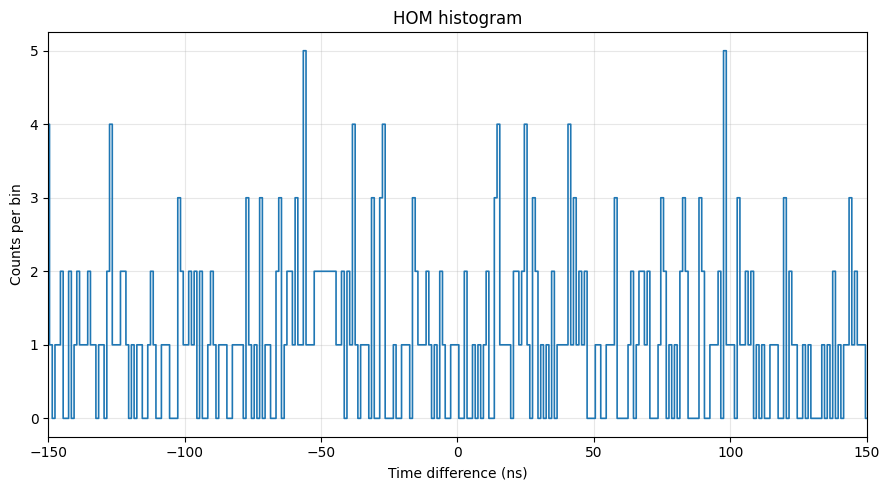

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

filename = r"C:\Users\oprs1\Measurement\Time Tagger\HOM\2026-07-07_112540 - 532 cw HOM (30min).txt"


# txt 읽기

def load_timetagger_txt(filename):
    df = pd.read_csv(filename, sep="\t")

    # column 이름 정리
    df.columns = [c.strip().replace('"', '') for c in df.columns]

    # 첫 번째 column: time, 두 번째 column: counts로 가정
    time_ps = df.iloc[:, 0].to_numpy(dtype=float)
    counts = df.iloc[:, 1].to_numpy(dtype=float)

    # ps -> ns 변환
    time_ns = time_ps / 1000.0

    return time_ns, counts


# Rebin 함수

def rebin_histogram(time_ns, counts, rebin_factor=5):
    """
    예:
    원래 bin width = 1 ns
    rebin_factor = 5
    -> 5 ns bin
    """
    n = len(counts)
    n_trim = (n // rebin_factor) * rebin_factor

    time_trim = time_ns[:n_trim]
    counts_trim = counts[:n_trim]

    time_rebin = time_trim.reshape(-1, rebin_factor).mean(axis=1)
    counts_rebin = counts_trim.reshape(-1, rebin_factor).sum(axis=1)

    return time_rebin, counts_rebin


# Plot 함수

def plot_timetagger_histogram(
    filename,
    rebin_factor=None,
    xlim=None,
    normalize=False,
    title=None
):
    time_ns, counts = load_timetagger_txt(filename)

    if rebin_factor is not None:
        time_ns, counts = rebin_histogram(
            time_ns,
            counts,
            rebin_factor=rebin_factor
        )

    y = counts.copy()

    if normalize:
        avg = np.mean(y)
        if avg > 0:
            y = y / avg

    plt.figure(figsize=(9, 5))
    plt.step(time_ns, y, where="mid", linewidth=1.2)

    plt.xlabel("Time difference (ns)")

    if normalize:
        plt.ylabel("Normalized counts")
    else:
        plt.ylabel("Counts per bin")

    if title is None:
        title = "Time Tagger histogram"
    plt.title(title)

    if xlim is not None:
        plt.xlim(xlim)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return time_ns, y


# Plot

time_ns, counts = plot_timetagger_histogram(
    filename,
    rebin_factor=1,
    xlim=(-150, 150),
    normalize=False,
    title="HOM histogram"
)

HOM Gaussian dip fitting parameters
y0       = 2.0103 ± 0.0517
x0       = -2.9983 ± 918.5327 ns
V        = 0.9847 ± 30.7602
sigma    = 0.2229 ± 204.6443 ns
FWHM     = 0.5250 ± 481.9005 ns
min/y0   = 0.0153


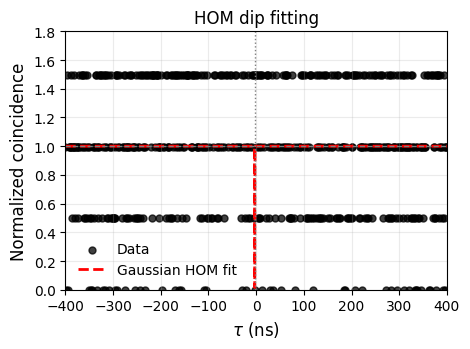

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# =========================
# 1. 파일 경로
# =========================

filename = r"C:\Users\oprs1\Measurement\Time Tagger\HOM\2026-07-07_112540 - 532 cw HOM (2h30min).txt"


# =========================
# 2. 데이터 읽기
# =========================

df = pd.read_csv(filename, sep="\t")
df.columns = df.columns.str.replace('"', '').str.strip()

time_ns = df["Time differences (ps)"].to_numpy(dtype=float) / 1000
count = df["Counts per bin"].to_numpy(dtype=float)


# =========================
# 3. 분석할 시간 구간 설정
# =========================

fit_min = -400      # ns
fit_max = 400     # ns

mask = (time_ns >= fit_min) & (time_ns <= fit_max)

x = time_ns[mask]
y = count[mask]


# =========================
# 4. HOM dip fitting model
# =========================

def hom_gaussian_dip(t, y0, x0, V, sigma):
    """
    Gaussian HOM dip model

    y0    : baseline coincidence count
    x0    : dip center, ns
    V     : dip depth, 0~1
    sigma : dip width, ns

    y(x0) = y0 * (1 - V)
    """
    return y0 * (1 - V * np.exp(-(t - x0)**2 / (2 * sigma**2)))


def hom_lorentzian_dip(t, y0, x0, V, gamma):
    """
    Lorentzian HOM dip model
    """
    return y0 * (1 - V / (1 + ((t - x0) / gamma)**2))


def hom_exponential_dip(t, y0, x0, V, tau):
    """
    Exponential HOM dip model
    """
    return y0 * (1 - V * np.exp(-np.abs(t - x0) / tau))


# =========================
# 5. 피팅할 dip 위치 설정
# =========================

# 보고 싶은 dip 위치
# 예: 0 ns, 40 ns, 80 ns 등
dip_guess = 0


# =========================
# 6. 초기값 설정
# =========================

# baseline은 전체 구간 평균으로 잡음
y0_init = np.mean(y)

# dip_guess 근처에서 가장 낮은 점을 x0 초기값으로 사용
search_width = 15  # ns

local_mask = (x >= dip_guess - search_width) & (x <= dip_guess + search_width)

if np.sum(local_mask) > 0:
    x0_init = x[local_mask][np.argmin(y[local_mask])]
    ymin_init = np.min(y[local_mask])
else:
    x0_init = dip_guess
    ymin_init = np.min(y)

V_init = 1 - ymin_init / y0_init

# 너무 이상한 초기값 방지
V_init = np.clip(V_init, 0.01, 0.9)

sigma_init = 5  # ns

p0 = [y0_init, x0_init, V_init, sigma_init]


# =========================
# 7. bound 설정
# =========================

bounds = (
    [0,       dip_guess - 20, 0,   0.1],
    [np.inf, dip_guess + 20, 1.0, 100]
)


# =========================
# 8. Poisson error
# =========================

sigma_y = np.sqrt(np.maximum(y, 1))


# =========================
# 9. fitting 실행
# =========================

popt, pcov = curve_fit(
    hom_gaussian_dip,
    x,
    y,
    p0=p0,
    bounds=bounds,
    sigma=sigma_y,
    absolute_sigma=True,
    maxfev=50000
)

y0, x0, V, sigma = popt

perr = np.sqrt(np.diag(pcov))
y0_err, x0_err, V_err, sigma_err = perr


# =========================
# 10. fitting curve
# =========================

xfit = np.linspace(x.min(), x.max(), 2000)
yfit = hom_gaussian_dip(xfit, *popt)

# normalized
g_data = y / y0
g_fit = yfit / y0

fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma
fwhm_err = 2 * np.sqrt(2 * np.log(2)) * sigma_err


# =========================
# 11. 결과 출력
# =========================

print("HOM Gaussian dip fitting parameters")
print(f"y0       = {y0:.4f} ± {y0_err:.4f}")
print(f"x0       = {x0:.4f} ± {x0_err:.4f} ns")
print(f"V        = {V:.4f} ± {V_err:.4f}")
print(f"sigma    = {sigma:.4f} ± {sigma_err:.4f} ns")
print(f"FWHM     = {fwhm:.4f} ± {fwhm_err:.4f} ns")
print(f"min/y0   = {1 - V:.4f}")


# =========================
# 12. plot
# =========================

plt.figure(figsize=(4.8, 3.6))

plt.scatter(x, g_data, s=25, color="black", alpha=0.75, label="Data")
plt.plot(xfit, g_fit, "r--", linewidth=2, label="Gaussian HOM fit")

plt.axhline(1, color="gray", linestyle="--", linewidth=1)
plt.axvline(x0, color="gray", linestyle=":", linewidth=1)

plt.xlabel(r"$\tau$ (ns)", fontsize=12)
plt.ylabel("Normalized coincidence", fontsize=12)

plt.xlim(fit_min, fit_max)
plt.ylim(0, 1.8)

plt.title("HOM dip fitting", fontsize=12)
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


===== Correlation fitting result =====
model_type = dip
fit range  = -400 ns to 400 ns
--------------------------------------
bg       = 21.8258 ± 0.166
x0       = 0.412593 ± 0.652
depth    = 9.10824 ± 2.48
width    = 1.81629 ± 0.653
--------------------------------------
min count        = 12.7176 counts/bin
depth/bg         = 0.417315 ± 0.114
FWHM             = 4.27703 ± 1.54 ns


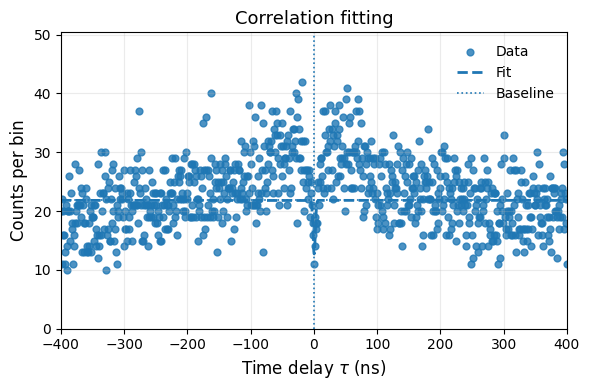

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# 1. User settings
# ============================================================

filename = r"C:\Users\oprs1\Measurement\Time Tagger\HOM\2026-07-08_093145 - 532 cw HOM (13h).txt"

# 분석할 시간 범위
t_min = -400   # ns
t_max = 400    # ns

# 예상 dip/correlation 중심
center_guess = 0   # ns. 0, 40, 80 등으로 바꿔가며 확인

# fitting model 선택
# "dip" : HOM-like correlation dip
# "g2"  : single-emitter g2 antibunching/bunching
model_type = "dip"

# plot 저장 여부
save_fig = False
save_path = "correlation_fit.png"


# ============================================================
# 2. Load Time Tagger txt
# ============================================================

def load_timetagger_txt(filename):
    df = pd.read_csv(filename, sep="\t")
    df.columns = df.columns.str.replace('"', '', regex=False).str.strip()

    # 보통 Time Tagger export 형식
    time_col = df.columns[0]
    count_col = df.columns[1]

    time_ps = df[time_col].to_numpy(dtype=float)
    counts = df[count_col].to_numpy(dtype=float)

    time_ns = time_ps / 1000.0

    return time_ns, counts


time_ns, counts = load_timetagger_txt(filename)


# ============================================================
# 3. Select fitting range
# ============================================================

mask = (time_ns >= t_min) & (time_ns <= t_max)

x = time_ns[mask]
y = counts[mask]

if len(x) < 10:
    raise ValueError("선택한 시간 구간에 데이터 포인트가 너무 적음. t_min, t_max 확인.")


# ============================================================
# 4. Models
# ============================================================

def hom_dip_model(t, bg, x0, depth, width):
    """
    HOM-like dip model.
    
    bg    : baseline counts/bin
    x0    : dip center, ns
    depth : dip depth in counts/bin
    width : Gaussian sigma, ns

    minimum = bg - depth
    """
    return bg - depth * np.exp(-(t - x0)**2 / (2 * width**2))


def g2_three_level_model(t, bg, x0, c, a, tau1, tau2):
    """
    3-level single-emitter correlation model.

    bg   : baseline counts/bin
    x0   : center, ns
    c    : antibunching contrast
    a    : bunching amplitude factor
    tau1 : antibunching time, ns
    tau2 : bunching time, ns

    y = bg * [1 - c * ((1+a) exp(-|t-x0|/tau1) - a exp(-|t-x0|/tau2))]
    """
    dt = np.abs(t - x0)
    return bg * (1 - c * ((1 + a) * np.exp(-dt / tau1) - a * np.exp(-dt / tau2)))


# ============================================================
# 5. Initial guesses
# ============================================================

def estimate_baseline(x, y, center_guess, exclude_width=20):
    """
    중심 근처를 제외한 영역으로 baseline 추정.
    """
    side_mask = np.abs(x - center_guess) > exclude_width

    if np.sum(side_mask) >= 5:
        return np.mean(y[side_mask])
    else:
        return np.mean(y)


bg_init = estimate_baseline(x, y, center_guess, exclude_width=20)

# center_guess 근처에서 minimum 찾기
search_width = 20
local_mask = (x >= center_guess - search_width) & (x <= center_guess + search_width)

if np.sum(local_mask) > 0:
    x0_init = x[local_mask][np.argmin(y[local_mask])]
    ymin_init = np.min(y[local_mask])
else:
    x0_init = center_guess
    ymin_init = np.min(y)

depth_init = max(bg_init - ymin_init, 0.1)
width_init = 5.0


# ============================================================
# 6. Fitting
# ============================================================

# Poisson error. count=0인 곳은 sigma=1로 둠.
sigma_y = np.sqrt(np.maximum(y, 1))

if model_type == "dip":
    model = hom_dip_model

    p0 = [
        bg_init,
        x0_init,
        depth_init,
        width_init
    ]

    bounds = (
        [0,       center_guess - 30, 0,       0.2],
        [np.inf, center_guess + 30, np.inf, 100]
    )

    param_names = ["bg", "x0", "depth", "width"]

elif model_type == "g2":
    model = g2_three_level_model

    c_init = np.clip(depth_init / bg_init, 0.01, 0.9)
    a_init = 0.1
    tau1_init = 5
    tau2_init = 50

    p0 = [
        bg_init,
        x0_init,
        c_init,
        a_init,
        tau1_init,
        tau2_init
    ]

    bounds = (
        [0,       center_guess - 30, 0, 0,   0.1,   1],
        [np.inf, center_guess + 30, 1, 10, 200, 1000]
    )

    param_names = ["bg", "x0", "c", "a", "tau1", "tau2"]

else:
    raise ValueError("model_type은 'dip' 또는 'g2'만 가능.")


popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    bounds=bounds,
    sigma=sigma_y,
    absolute_sigma=True,
    maxfev=100000
)

perr = np.sqrt(np.diag(pcov))


# ============================================================
# 7. Fit result
# ============================================================

xfit = np.linspace(x.min(), x.max(), 3000)
yfit = model(xfit, *popt)

print("\n===== Correlation fitting result =====")
print(f"model_type = {model_type}")
print(f"fit range  = {t_min} ns to {t_max} ns")
print("--------------------------------------")

for name, val, err in zip(param_names, popt, perr):
    print(f"{name:8s} = {val:.6g} ± {err:.3g}")

if model_type == "dip":
    bg, x0, depth, width = popt
    bg_err, x0_err, depth_err, width_err = perr

    visibility_like = depth / bg
    min_count = bg - depth
    fwhm = 2 * np.sqrt(2 * np.log(2)) * width

    # error propagation, rough
    visibility_err = visibility_like * np.sqrt((depth_err / depth)**2 + (bg_err / bg)**2) if depth > 0 and bg > 0 else np.nan
    fwhm_err = 2 * np.sqrt(2 * np.log(2)) * width_err

    print("--------------------------------------")
    print(f"min count        = {min_count:.6g} counts/bin")
    print(f"depth/bg         = {visibility_like:.6g} ± {visibility_err:.3g}")
    print(f"FWHM             = {fwhm:.6g} ± {fwhm_err:.3g} ns")

elif model_type == "g2":
    bg, x0, c, a, tau1, tau2 = popt
    g2_zero_like = 1 - c

    print("--------------------------------------")
    print(f"g2-like minimum  = {g2_zero_like:.6g}")


# ============================================================
# 8. Plot raw counts
# ============================================================

plt.figure(figsize=(6.0, 4.0))

plt.scatter(x, y, s=24, alpha=0.8, label="Data")
plt.plot(xfit, yfit, "--", linewidth=2.0, label="Fit")

if model_type == "dip":
    plt.axhline(popt[0], linestyle=":", linewidth=1.2, label="Baseline")
    plt.axvline(popt[1], linestyle=":", linewidth=1.2)
elif model_type == "g2":
    plt.axhline(popt[0], linestyle=":", linewidth=1.2, label="Baseline")
    plt.axvline(popt[1], linestyle=":", linewidth=1.2)

plt.xlabel(r"Time delay $\tau$ (ns)", fontsize=12)
plt.ylabel("Counts per bin", fontsize=12)
plt.title("Correlation fitting", fontsize=13)

plt.xlim(t_min, t_max)
plt.ylim(0, max(np.max(y), np.max(yfit)) * 1.2)

plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()

if save_fig:
    plt.savefig(save_path, dpi=300)

plt.show()

===== HOM dip fitting result =====
Model      = gaussian
Fit range  = -80 ns to 80 ns
----------------------------------
b0         = 30.6135 ± 0.8675 counts/bin
b1         = 0.010808 ± 0.008969 counts/bin/ns
b2         = -0.00069474 ± 0.00025675 counts/bin/ns^2
x0         = 0.3607 ± 0.9103 ns
A          = 14.5145 ± 1.6246 counts/bin
sigma     = 6.6661 ± 1.0403 ns
----------------------------------
Baseline at x0 = 30.6173 counts/bin
Normalized min = 0.5259
Visibility-like dip depth = 0.4741 ± 0.0547
FWHM       = 15.6974 ± 2.4496 ns


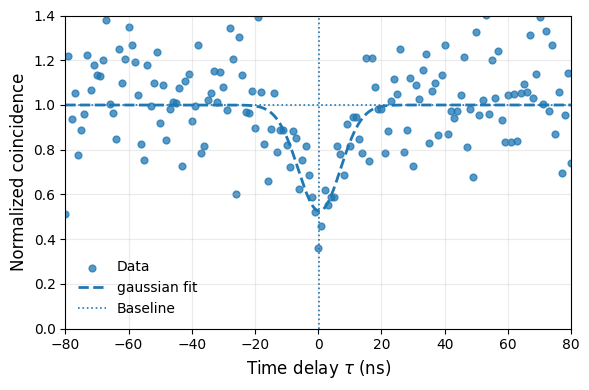

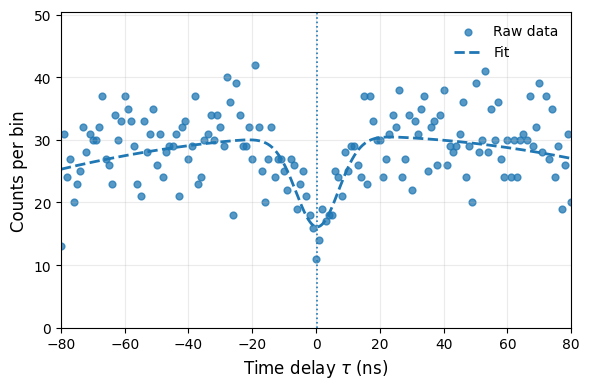

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# 1. User settings
# ============================================================

filename = r"C:\Users\oprs1\Measurement\Time Tagger\HOM\2026-07-08_093145 - 532 cw HOM (13h).txt"

# fitting 구간
fit_min = -80     # ns
fit_max = 80      # ns

# dip 예상 위치
# 지금 데이터에서 0 ns dip을 볼 거면 0
# 40 ns, 80 ns 근처를 보고 싶으면 바꾸면 됨
center_guess = 0  # ns

# dip 중심을 찾을 수 있는 허용 범위
center_bound = 10  # ns

# dip 주변을 baseline 추정에서 제외할 범위
exclude_width = 15  # ns

# plot 범위
plot_min = fit_min
plot_max = fit_max

# Gaussian / Lorentzian 중 선택
model_type = "gaussian"   # "gaussian" or "lorentzian"


# ============================================================
# 2. Load Time Tagger histogram
# ============================================================

df = pd.read_csv(filename, sep="\t")
df.columns = df.columns.str.replace('"', '', regex=False).str.strip()

time_ps = df.iloc[:, 0].to_numpy(dtype=float)
count = df.iloc[:, 1].to_numpy(dtype=float)

time_ns = time_ps / 1000.0


# ============================================================
# 3. Select fitting region
# ============================================================

mask = (time_ns >= fit_min) & (time_ns <= fit_max)

x = time_ns[mask]
y = count[mask]

if len(x) < 20:
    raise ValueError("Fitting range가 너무 좁거나 데이터가 부족함.")


# ============================================================
# 4. Baseline + dip models
# ============================================================

def baseline_poly(t, b0, b1, b2):
    """
    Slowly varying background.
    t는 ns.
    """
    tc = t - center_guess
    return b0 + b1 * tc + b2 * tc**2


def gaussian_dip_model(t, b0, b1, b2, x0, A, sigma):
    """
    Raw count fitting model:
    count = baseline - Gaussian dip

    A     : dip amplitude in counts/bin
    sigma : Gaussian sigma in ns
    """
    bg = baseline_poly(t, b0, b1, b2)
    dip = A * np.exp(-(t - x0)**2 / (2 * sigma**2))
    return bg - dip


def lorentzian_dip_model(t, b0, b1, b2, x0, A, gamma):
    """
    Raw count fitting model:
    count = baseline - Lorentzian dip

    gamma : HWHM-like width in ns
    """
    bg = baseline_poly(t, b0, b1, b2)
    dip = A / (1 + ((t - x0) / gamma)**2)
    return bg - dip


if model_type == "gaussian":
    fit_model = gaussian_dip_model
elif model_type == "lorentzian":
    fit_model = lorentzian_dip_model
else:
    raise ValueError("model_type은 'gaussian' 또는 'lorentzian'만 가능.")


# ============================================================
# 5. Initial guess
# ============================================================

# baseline은 dip 주변을 제외한 영역으로 먼저 추정
side_mask = np.abs(x - center_guess) > exclude_width

if np.sum(side_mask) < 10:
    side_mask = np.ones_like(x, dtype=bool)

# 2차 polynomial baseline rough fit
coef = np.polyfit(x[side_mask] - center_guess, y[side_mask], deg=2)
b2_init, b1_init, b0_init = coef

# dip center 초기값: center_guess 근처에서 최솟값
local_mask = (x >= center_guess - center_bound) & (x <= center_guess + center_bound)

if np.sum(local_mask) > 0:
    x0_init = x[local_mask][np.argmin(y[local_mask])]
    ymin_init = np.min(y[local_mask])
else:
    x0_init = center_guess
    ymin_init = np.min(y)

bg_at_x0_init = baseline_poly(x0_init, b0_init, b1_init, b2_init)

A_init = max(bg_at_x0_init - ymin_init, 0.1)

# width 초기값
width_init = 5.0  # ns

p0 = [b0_init, b1_init, b2_init, x0_init, A_init, width_init]


# ============================================================
# 6. Bounds
# ============================================================

# baseline polynomial은 너무 빡세게 bound 안 걸고,
# dip amplitude와 width, center만 물리적으로 제한
lower_bounds = [
    0,                    # b0
    -np.inf,              # b1
    -np.inf,              # b2
    center_guess - center_bound,  # x0
    0,                    # A
    0.2                   # sigma or gamma
]

upper_bounds = [
    np.inf,               # b0
    np.inf,               # b1
    np.inf,               # b2
    center_guess + center_bound,  # x0
    np.inf,               # A
    50                    # sigma or gamma
]


# ============================================================
# 7. Weighted fitting
# ============================================================

# Poisson error: sigma_y ~ sqrt(count)
sigma_y = np.sqrt(np.maximum(y, 1))

popt, pcov = curve_fit(
    fit_model,
    x,
    y,
    p0=p0,
    bounds=(lower_bounds, upper_bounds),
    sigma=sigma_y,
    absolute_sigma=True,
    maxfev=200000
)

perr = np.sqrt(np.diag(pcov))

b0, b1, b2, x0, A, width = popt
b0_err, b1_err, b2_err, x0_err, A_err, width_err = perr


# ============================================================
# 8. Derived quantities
# ============================================================

bg_x0 = baseline_poly(x0, b0, b1, b2)

visibility = A / bg_x0
min_norm = 1 - visibility

# rough error propagation
visibility_err = visibility * np.sqrt((A_err / A)**2 + (b0_err / bg_x0)**2) if A > 0 and bg_x0 > 0 else np.nan

if model_type == "gaussian":
    fwhm = 2 * np.sqrt(2 * np.log(2)) * width
    fwhm_err = 2 * np.sqrt(2 * np.log(2)) * width_err
    width_name = "sigma"
else:
    fwhm = 2 * width
    fwhm_err = 2 * width_err
    width_name = "gamma"


# ============================================================
# 9. Generate fit curve and normalize
# ============================================================

xfit = np.linspace(x.min(), x.max(), 3000)

yfit = fit_model(xfit, *popt)
bg_fit = baseline_poly(xfit, b0, b1, b2)

bg_data = baseline_poly(x, b0, b1, b2)

y_norm = y / bg_data
yfit_norm = yfit / bg_fit


# ============================================================
# 10. Print results
# ============================================================

print("===== HOM dip fitting result =====")
print(f"Model      = {model_type}")
print(f"Fit range  = {fit_min} ns to {fit_max} ns")
print("----------------------------------")
print(f"b0         = {b0:.4f} ± {b0_err:.4f} counts/bin")
print(f"b1         = {b1:.6f} ± {b1_err:.6f} counts/bin/ns")
print(f"b2         = {b2:.8f} ± {b2_err:.8f} counts/bin/ns^2")
print(f"x0         = {x0:.4f} ± {x0_err:.4f} ns")
print(f"A          = {A:.4f} ± {A_err:.4f} counts/bin")
print(f"{width_name:<10s}= {width:.4f} ± {width_err:.4f} ns")
print("----------------------------------")
print(f"Baseline at x0 = {bg_x0:.4f} counts/bin")
print(f"Normalized min = {min_norm:.4f}")
print(f"Visibility-like dip depth = {visibility:.4f} ± {visibility_err:.4f}")
print(f"FWHM       = {fwhm:.4f} ± {fwhm_err:.4f} ns")


# ============================================================
# 11. Plot normalized result
# ============================================================

plt.figure(figsize=(6.0, 4.0))

plt.scatter(x, y_norm, s=24, alpha=0.75, label="Data")
plt.plot(xfit, yfit_norm, "--", linewidth=2.0, label=f"{model_type} fit")

plt.axhline(1, linestyle=":", linewidth=1.2, label="Baseline")
plt.axvline(x0, linestyle=":", linewidth=1.2)

plt.xlabel(r"Time delay $\tau$ (ns)", fontsize=12)
plt.ylabel("Normalized coincidence", fontsize=12)

# plt.title("HOM dip", fontsize=13)
plt.xlim(plot_min, plot_max)
plt.ylim(0, 1.4)

plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# ============================================================
# 12. Optional: raw count plot
# ============================================================

plt.figure(figsize=(6.0, 4.0))

plt.scatter(x, y, s=24, alpha=0.75, label="Raw data")
plt.plot(xfit, yfit, "--", linewidth=2.0, label="Fit")

plt.axvline(x0, linestyle=":", linewidth=1.2)

plt.xlabel(r"Time delay $\tau$ (ns)", fontsize=12)
plt.ylabel("Counts per bin", fontsize=12)

# plt.title("Raw correlation histogram", fontsize=13)
plt.xlim(plot_min, plot_max)
plt.ylim(0, max(np.max(y), np.max(yfit)) * 1.2)

plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 3. Select fitting region
# ============================================================

fit_min = np.min(time_ns)
fit_max = np.max(time_ns)

plot_min = fit_min
plot_max = fit_max

mask = (time_ns >= fit_min) & (time_ns <= fit_max)

x = time_ns[mask]
y = count[mask]

===== Data information =====
Data range      = -500.0 ns to 499.0 ns
Number of bins  = 1000
Total counts    = 22458
Mean counts/bin = 22.4580

===== HOM dip fitting result =====
Model       = gaussian
Fit range   = -500.0 ns to 499.0 ns
-----------------------------------
b0          = 26.4216 ± 0.307
b1          = -0.000205015 ± 0.00124
b2          = -0.000107443 ± 7.02e-06
b3          = 4.69908e-09 ± 7.48e-09
b4          = 3.26393e-10 ± 3.04e-11
-----------------------------------
x0          = 0.6977 ± 0.7434 ns
A           = 12.1973 ± 1.8856 counts/bin
sigma      = 3.6679 ± 0.7666 ns
-----------------------------------
Baseline@x0 = 26.4214 counts/bin
Min norm    = 0.5384
Dip depth   = 0.4616 ± 0.0716
FWHM        = 8.6373 ± 1.8053 ns


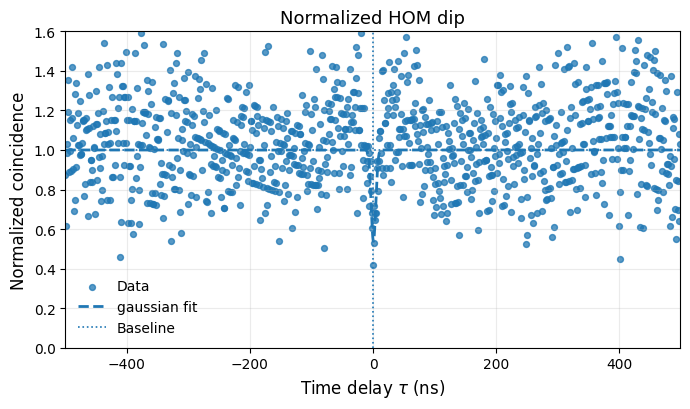

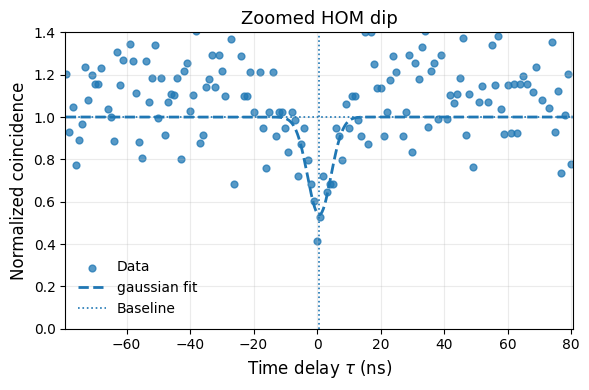

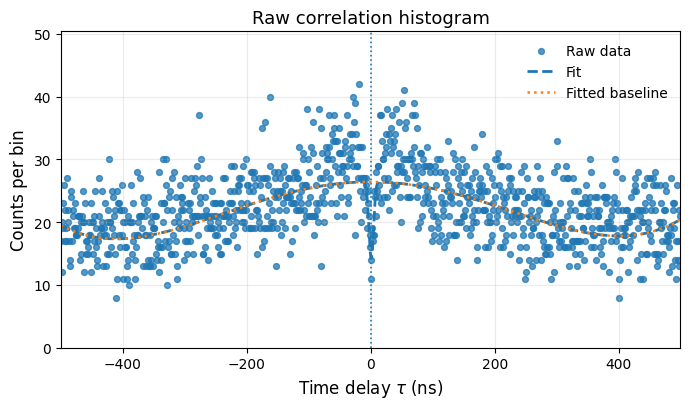

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ============================================================
# 1. User settings
# ============================================================

filename = r"C:\Users\oprs1\Measurement\Time Tagger\HOM\2026-07-08_093145 - 532 cw HOM (13h).txt"

# dip 예상 위치
# 0 ns dip이면 0
# 40 ns 근처 dip이면 40
# 80 ns 근처 dip이면 80
center_guess = 0  # ns

# dip 중심이 움직일 수 있는 허용 범위
center_bound = 10  # ns

# baseline fitting할 때 dip 주변 제외 범위
exclude_width = 20  # ns

# fitting model
# "gaussian" 또는 "lorentzian"
model_type = "gaussian"

# zoom plot 범위: x0 ± zoom_width
zoom_width = 80  # ns

# figure 저장 여부
save_fig = False
save_path_norm = "HOM_normalized_fit.png"
save_path_zoom = "HOM_zoomed_fit.png"
save_path_raw = "HOM_raw_fit.png"


# ============================================================
# 2. Load Time Tagger txt
# ============================================================

df = pd.read_csv(filename, sep="\t")
df.columns = df.columns.str.replace('"', '', regex=False).str.strip()

time_ps = df.iloc[:, 0].to_numpy(dtype=float)
count = df.iloc[:, 1].to_numpy(dtype=float)

time_ns = time_ps / 1000.0


# ============================================================
# 3. Use full data range
# ============================================================

x = time_ns.copy()
y = count.copy()

fit_min = np.min(x)
fit_max = np.max(x)

print("===== Data information =====")
print(f"Data range      = {fit_min:.1f} ns to {fit_max:.1f} ns")
print(f"Number of bins  = {len(x)}")
print(f"Total counts    = {np.sum(y):.0f}")
print(f"Mean counts/bin = {np.mean(y):.4f}")


# ============================================================
# 4. Baseline and dip models
# ============================================================

def baseline_poly4(t, b0, b1, b2, b3, b4):
    """
    4th-order polynomial baseline.
    전체 histogram의 완만한 envelope를 잡기 위한 baseline.
    """
    tc = t - center_guess
    return b0 + b1*tc + b2*tc**2 + b3*tc**3 + b4*tc**4


def gaussian_dip_model(t, b0, b1, b2, b3, b4, x0, A, sigma):
    """
    Raw count model:
    count = baseline - Gaussian dip
    """
    bg = baseline_poly4(t, b0, b1, b2, b3, b4)
    dip = A * np.exp(-(t - x0)**2 / (2 * sigma**2))
    return bg - dip


def lorentzian_dip_model(t, b0, b1, b2, b3, b4, x0, A, gamma):
    """
    Raw count model:
    count = baseline - Lorentzian dip
    """
    bg = baseline_poly4(t, b0, b1, b2, b3, b4)
    dip = A / (1 + ((t - x0) / gamma)**2)
    return bg - dip


if model_type == "gaussian":
    fit_model = gaussian_dip_model
    width_name = "sigma"
elif model_type == "lorentzian":
    fit_model = lorentzian_dip_model
    width_name = "gamma"
else:
    raise ValueError("model_type은 'gaussian' 또는 'lorentzian'만 가능")


# ============================================================
# 5. Initial guess
# ============================================================

# dip 주변을 제외하고 baseline 초기값 추정
side_mask = np.abs(x - center_guess) > exclude_width

if np.sum(side_mask) < 20:
    side_mask = np.ones_like(x, dtype=bool)

# 4차 polynomial 초기 fit
# np.polyfit은 높은 차수부터 반환: p4, p3, p2, p1, p0
p4, p3, p2, p1, p0 = np.polyfit(
    x[side_mask] - center_guess,
    y[side_mask],
    deg=4
)

b0_init = p0
b1_init = p1
b2_init = p2
b3_init = p3
b4_init = p4

# dip center 초기값: center_guess 주변에서 count가 가장 낮은 지점
local_mask = (x >= center_guess - center_bound) & (x <= center_guess + center_bound)

if np.sum(local_mask) > 0:
    x0_init = x[local_mask][np.argmin(y[local_mask])]
    ymin_init = np.min(y[local_mask])
else:
    x0_init = center_guess
    ymin_init = np.min(y)

bg_at_x0_init = baseline_poly4(
    x0_init,
    b0_init,
    b1_init,
    b2_init,
    b3_init,
    b4_init
)

A_init = max(bg_at_x0_init - ymin_init, 0.1)

# width 초기값, ns
width_init = 5.0

p0_fit = [
    b0_init,
    b1_init,
    b2_init,
    b3_init,
    b4_init,
    x0_init,
    A_init,
    width_init
]


# ============================================================
# 6. Bounds
# ============================================================

lower_bounds = [
    0,                              # b0
    -np.inf,                        # b1
    -np.inf,                        # b2
    -np.inf,                        # b3
    -np.inf,                        # b4
    center_guess - center_bound,    # x0
    0,                              # A
    0.2                             # sigma/gamma
]

upper_bounds = [
    np.inf,                         # b0
    np.inf,                         # b1
    np.inf,                         # b2
    np.inf,                         # b3
    np.inf,                         # b4
    center_guess + center_bound,    # x0
    np.inf,                         # A
    100                             # sigma/gamma
]


# ============================================================
# 7. Weighted fitting
# ============================================================

# Poisson error
sigma_y = np.sqrt(np.maximum(y, 1))

popt, pcov = curve_fit(
    fit_model,
    x,
    y,
    p0=p0_fit,
    bounds=(lower_bounds, upper_bounds),
    sigma=sigma_y,
    absolute_sigma=True,
    maxfev=300000
)

perr = np.sqrt(np.diag(pcov))

b0, b1, b2, b3, b4, x0, A, width = popt
b0_err, b1_err, b2_err, b3_err, b4_err, x0_err, A_err, width_err = perr


# ============================================================
# 8. Derived quantities
# ============================================================

bg_x0 = baseline_poly4(x0, b0, b1, b2, b3, b4)

dip_depth = A / bg_x0
min_norm = 1 - dip_depth

if A > 0 and bg_x0 > 0:
    dip_depth_err = dip_depth * np.sqrt((A_err / A)**2 + (b0_err / bg_x0)**2)
else:
    dip_depth_err = np.nan

if model_type == "gaussian":
    fwhm = 2 * np.sqrt(2 * np.log(2)) * width
    fwhm_err = 2 * np.sqrt(2 * np.log(2)) * width_err
else:
    fwhm = 2 * width
    fwhm_err = 2 * width_err


# ============================================================
# 9. Fit curve and normalization
# ============================================================

xfit = np.linspace(fit_min, fit_max, 5000)

yfit = fit_model(xfit, *popt)
bg_fit = baseline_poly4(xfit, b0, b1, b2, b3, b4)

bg_data = baseline_poly4(x, b0, b1, b2, b3, b4)

# normalize by fitted baseline
y_norm = y / bg_data
yfit_norm = yfit / bg_fit


# ============================================================
# 10. Print results
# ============================================================

print("\n===== HOM dip fitting result =====")
print(f"Model       = {model_type}")
print(f"Fit range   = {fit_min:.1f} ns to {fit_max:.1f} ns")
print("-----------------------------------")
print(f"b0          = {b0:.6g} ± {b0_err:.3g}")
print(f"b1          = {b1:.6g} ± {b1_err:.3g}")
print(f"b2          = {b2:.6g} ± {b2_err:.3g}")
print(f"b3          = {b3:.6g} ± {b3_err:.3g}")
print(f"b4          = {b4:.6g} ± {b4_err:.3g}")
print("-----------------------------------")
print(f"x0          = {x0:.4f} ± {x0_err:.4f} ns")
print(f"A           = {A:.4f} ± {A_err:.4f} counts/bin")
print(f"{width_name:<11s}= {width:.4f} ± {width_err:.4f} ns")
print("-----------------------------------")
print(f"Baseline@x0 = {bg_x0:.4f} counts/bin")
print(f"Min norm    = {min_norm:.4f}")
print(f"Dip depth   = {dip_depth:.4f} ± {dip_depth_err:.4f}")
print(f"FWHM        = {fwhm:.4f} ± {fwhm_err:.4f} ns")


# ============================================================
# 11. Plot normalized full data
# ============================================================

plt.figure(figsize=(7.0, 4.2))

# 데이터는 점만
plt.scatter(
    x,
    y_norm,
    s=18,
    alpha=0.75,
    label="Data"
)

# fit은 선
plt.plot(
    xfit,
    yfit_norm,
    "--",
    linewidth=2.0,
    label=f"{model_type} fit"
)

plt.axhline(1, linestyle=":", linewidth=1.2, label="Baseline")
plt.axvline(x0, linestyle=":", linewidth=1.2)

plt.xlabel(r"Time delay $\tau$ (ns)", fontsize=12)
plt.ylabel("Normalized coincidence", fontsize=12)
plt.title("Normalized HOM dip", fontsize=13)

plt.xlim(fit_min, fit_max)
plt.ylim(0, 1.6)

plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()

if save_fig:
    plt.savefig(save_path_norm, dpi=300)

plt.show()


# ============================================================
# 12. Plot zoomed normalized dip
# ============================================================

plt.figure(figsize=(6.0, 4.0))

zoom_mask = (x >= x0 - zoom_width) & (x <= x0 + zoom_width)
zoom_fit_mask = (xfit >= x0 - zoom_width) & (xfit <= x0 + zoom_width)

# 데이터는 점만
plt.scatter(
    x[zoom_mask],
    y_norm[zoom_mask],
    s=24,
    alpha=0.75,
    label="Data"
)

# fit은 선
plt.plot(
    xfit[zoom_fit_mask],
    yfit_norm[zoom_fit_mask],
    "--",
    linewidth=2.0,
    label=f"{model_type} fit"
)

plt.axhline(1, linestyle=":", linewidth=1.2, label="Baseline")
plt.axvline(x0, linestyle=":", linewidth=1.2)

plt.xlabel(r"Time delay $\tau$ (ns)", fontsize=12)
plt.ylabel("Normalized coincidence", fontsize=12)
plt.title("Zoomed HOM dip", fontsize=13)

plt.xlim(x0 - zoom_width, x0 + zoom_width)
plt.ylim(0, 1.4)

plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()

if save_fig:
    plt.savefig(save_path_zoom, dpi=300)

plt.show()


# ============================================================
# 13. Plot raw count data
# ============================================================

plt.figure(figsize=(7.0, 4.2))

# raw 데이터도 점만
plt.scatter(
    x,
    y,
    s=18,
    alpha=0.75,
    label="Raw data"
)

plt.plot(
    xfit,
    yfit,
    "--",
    linewidth=2.0,
    label="Fit"
)

plt.plot(
    xfit,
    bg_fit,
    ":",
    linewidth=1.8,
    label="Fitted baseline"
)

plt.axvline(x0, linestyle=":", linewidth=1.2)

plt.xlabel(r"Time delay $\tau$ (ns)", fontsize=12)
plt.ylabel("Counts per bin", fontsize=12)
plt.title("Raw correlation histogram", fontsize=13)

plt.xlim(fit_min, fit_max)
plt.ylim(0, max(np.max(y), np.max(yfit)) * 1.2)

plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout()

if save_fig:
    plt.savefig(save_path_raw, dpi=300)

plt.show()

## pulse

CSV 파일의 열 개수: 5
처음 5줄:
                 0             1        2             3       4
0    Record Length  2.000000e+03   Points -7.400000e-08  0.9160
1  Sample Interval  1.000000e-10        s -7.390000e-08  0.9176
2    Trigger Point  7.400000e+02  Samples -7.380000e-08  0.9184
3     Trigger Time  1.500000e-12        s -7.370000e-08  0.9176
4              NaN           NaN      NaN -7.360000e-08  0.9184
0.989600042
File 1: Baseline = 0.9186, Max (after baseline) = 0.0710
1.45600002
File 2: Baseline = -0.0025, Max (after baseline) = 1.4585


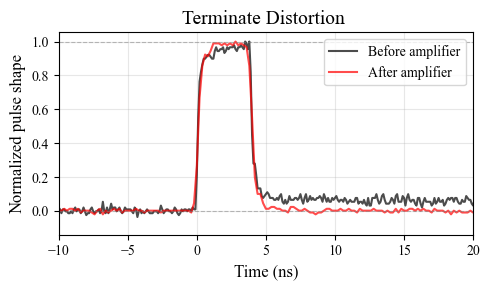

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 파일 경로
filenames = [
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_123747_ch2.csv',
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_124917_ch2.csv'
    ]
plt.figure(figsize=(5, 3))

# 각 파일을 읽어서 그래프에 추가
color = ['black', 'red']
for i, filename in enumerate(filenames, 1):
    df = pd.read_csv(filename, header=None)
    
    # 첫 번째 파일에서만 CSV 구조 확인
    if i == 1:
        print(f"CSV 파일의 열 개수: {len(df.columns)}")
        print(f"처음 5줄:\n{df.head()}")
    
    # 4번째 열(D열)을 x축, 5번째 열(E열)을 y축으로 사용
    x_data = df.iloc[:, 3]
    y_data = df.iloc[:, 4]
    print(y_data.max())
    # x축이 -0.5에서 -0.1 범위의 y값 평균 계산 (baseline)
    baseline_mask = (x_data >= -0.5e-7) & (x_data <= -0.1e-7)
    baseline_data = y_data[baseline_mask]
    
    if len(baseline_data) > 0:
        baseline_mean = baseline_data.mean()
        
        # 전체 데이터에서 baseline을 빼기 (0점 설정)
        y_corrected = y_data - baseline_mean
        
        # 최대값으로 정규화 (최대값을 1로 만들기)
        y_max = y_corrected.max()
        if y_max > 0:
            y_normalized = y_corrected / y_max
            
            plt.plot(x_data*1e9, y_normalized, color=color[i-1], linewidth=1.5, label=f'File {i}', alpha=0.7)
            print(f"File {i}: Baseline = {baseline_mean:.4f}, Max (after baseline) = {y_max:.4f}")
        else:
            print(f"File {i}: baseline 보정 후 최대값이 0 이하입니다.")
    else:
        print(f"File {i}: -0.5 ~ -0.1 범위에 데이터가 없습니다.")

plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Normalized pulse shape', fontsize=12)
plt.title('Terminate Distortion ', fontsize=14)
plt.legend(['Before amplifier', 'After amplifier'], loc = 'upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-10, 20)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

CSV 파일의 열 개수: 5
처음 5줄:
                 0             1        2             3       4
0    Record Length  2.000000e+03   Points -7.400000e-08  0.9160
1  Sample Interval  1.000000e-10        s -7.390000e-08  0.9176
2    Trigger Point  7.400000e+02  Samples -7.380000e-08  0.9184
3     Trigger Time  1.500000e-12        s -7.370000e-08  0.9176
4              NaN           NaN      NaN -7.360000e-08  0.9184
0.989600042
File 1: Baseline = 0.9186, Max (after baseline) = 0.0710
1.45600002
File 2: Baseline = -0.0025, Max (after baseline) = 1.4585


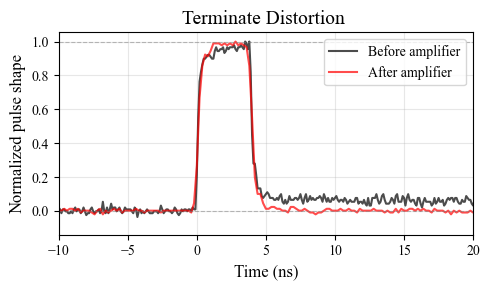

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 파일 경로
filenames = [
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_123747_ch2.csv',
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_124917_ch2.csv'
    ]
plt.figure(figsize=(5, 3))

# 각 파일을 읽어서 그래프에 추가
color = ['black', 'red']
for i, filename in enumerate(filenames, 1):
    df = pd.read_csv(filename, header=None)
    
    # 첫 번째 파일에서만 CSV 구조 확인
    if i == 1:
        print(f"CSV 파일의 열 개수: {len(df.columns)}")
        print(f"처음 5줄:\n{df.head()}")
    
    # 4번째 열(D열)을 x축, 5번째 열(E열)을 y축으로 사용
    x_data = df.iloc[:, 3]
    y_data = df.iloc[:, 4]
    print(y_data.max())
    # x축이 -0.5에서 -0.1 범위의 y값 평균 계산 (baseline)
    baseline_mask = (x_data >= -0.5e-7) & (x_data <= -0.1e-7)
    baseline_data = y_data[baseline_mask]
    
    if len(baseline_data) > 0:
        baseline_mean = baseline_data.mean()
        
        # 전체 데이터에서 baseline을 빼기 (0점 설정)
        y_corrected = y_data - baseline_mean
        
        # 최대값으로 정규화 (최대값을 1로 만들기)
        y_max = y_corrected.max()
        if y_max > 0:
            y_normalized = y_corrected / y_max
            
            plt.plot(x_data*1e9, y_normalized, color=color[i-1], linewidth=1.5, label=f'File {i}', alpha=0.7)
            print(f"File {i}: Baseline = {baseline_mean:.4f}, Max (after baseline) = {y_max:.4f}")
        else:
            print(f"File {i}: baseline 보정 후 최대값이 0 이하입니다.")
    else:
        print(f"File {i}: -0.5 ~ -0.1 범위에 데이터가 없습니다.")

plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Normalized pulse shape', fontsize=12)
plt.title('Terminate Distortion ', fontsize=14)
plt.legend(['Before amplifier', 'After amplifier'], loc = 'upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-10, 20)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

CSV 파일의 열 개수: 5
처음 5줄:
                 0             1        2             3       4
0    Record Length  2.000000e+03   Points -7.400000e-08  0.9184
1  Sample Interval  1.000000e-10        s -7.390000e-08  0.9176
2    Trigger Point  7.400000e+02  Samples -7.380000e-08  0.9184
3     Trigger Time  7.635265e-11        s -7.370000e-08  0.9184
4              NaN           NaN      NaN -7.360000e-08  0.9184
0.989600042
File 1: Baseline = 0.9183, Max (after baseline) = 0.0713
1.45600002
File 2: Baseline = 0.0002, Max (after baseline) = 1.4558


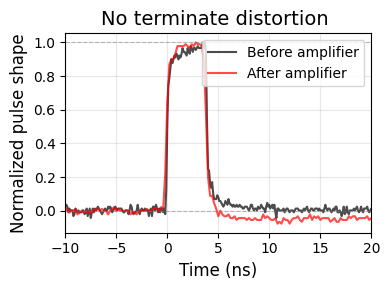

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 파일 경로
filenames = [
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_123903_ch2.csv',
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_125002_ch2.csv'
]

plt.figure(figsize=(4, 3))

# 각 파일을 읽어서 그래프에 추가
color = ['black', 'red']
for i, filename in enumerate(filenames, 1):
    df = pd.read_csv(filename, header=None)
    
    # 첫 번째 파일에서만 CSV 구조 확인
    if i == 1:
        print(f"CSV 파일의 열 개수: {len(df.columns)}")
        print(f"처음 5줄:\n{df.head()}")
    
    # 4번째 열(D열)을 x축, 5번째 열(E열)을 y축으로 사용
    x_data = df.iloc[:, 3]
    y_data = df.iloc[:, 4]
    print(y_data.max())
    # x축이 -0.5에서 -0.1 범위의 y값 평균 계산 (baseline)
    baseline_mask = (x_data >= -0.5e-7) & (x_data <= -0.1e-7)
    baseline_data = y_data[baseline_mask]
    
    if len(baseline_data) > 0:
        baseline_mean = baseline_data.mean()
        
        # 전체 데이터에서 baseline을 빼기 (0점 설정)
        y_corrected = y_data - baseline_mean
        
        # 최대값으로 정규화 (최대값을 1로 만들기)
        y_max = y_corrected.max()
        if y_max > 0:
            y_normalized = y_corrected / y_max
            
            plt.plot(x_data*1e9, y_normalized, color=color[i-1], linewidth=1.5, label=f'File {i}', alpha=0.7)
            print(f"File {i}: Baseline = {baseline_mean:.4f}, Max (after baseline) = {y_max:.4f}")
        else:
            print(f"File {i}: baseline 보정 후 최대값이 0 이하입니다.")
    else:
        print(f"File {i}: -0.5 ~ -0.1 범위에 데이터가 없습니다.")

plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Normalized pulse shape', fontsize=12)
plt.title('No terminate distortion ', fontsize=14)
plt.legend(['Before amplifier', 'After amplifier'], loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-10, 20)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

CSV 파일의 열 개수: 5
처음 5줄:
                 0             1        2             3             4
0    Record Length  1.000000e+03   Points -8.000000e-08  5.215406e-10
1  Sample Interval  2.000000e-10        s -7.980000e-08  1.600000e-02
2    Trigger Point  4.000000e+02  Samples -7.960000e-08  5.215406e-10
3     Trigger Time  1.652456e-11        s -7.940000e-08  1.600000e-02
4              NaN           NaN      NaN -7.920000e-08  1.600000e-02
1.45600002
File 1: Baseline = -0.0025, Max (after baseline) = 1.4585
1.45600002
File 2: Baseline = 0.0002, Max (after baseline) = 1.4558


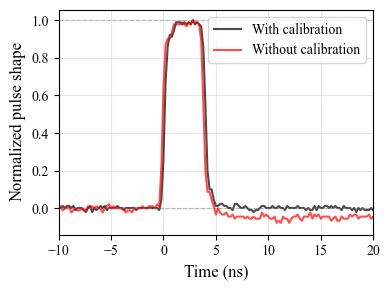

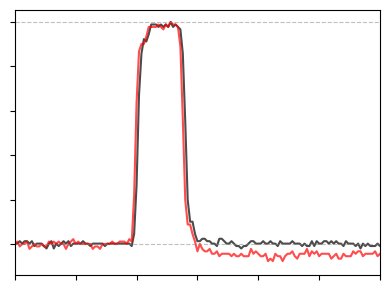

In [314]:
# with amplifier
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 파일 경로
filenames = [
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_124917_ch2.csv',
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_125002_ch2.csv'
]

plt.figure(figsize=(4, 3))

# 각 파일을 읽어서 그래프에 추가
color = ['black', 'red']
for i, filename in enumerate(filenames, 1):
    df = pd.read_csv(filename, header=None)
    
    # 첫 번째 파일에서만 CSV 구조 확인
    if i == 1:
        print(f"CSV 파일의 열 개수: {len(df.columns)}")
        print(f"처음 5줄:\n{df.head()}")
    
    # 4번째 열(D열)을 x축, 5번째 열(E열)을 y축으로 사용
    x_data = df.iloc[:, 3]
    y_data = df.iloc[:, 4]
    print(y_data.max())
    # x축이 -0.5에서 -0.1 범위의 y값 평균 계산 (baseline)
    baseline_mask = (x_data >= -0.5e-7) & (x_data <= -0.1e-7)
    baseline_data = y_data[baseline_mask]
    
    if len(baseline_data) > 0:
        baseline_mean = baseline_data.mean()
        
        # 전체 데이터에서 baseline을 빼기 (0점 설정)
        y_corrected = y_data - baseline_mean
        
        # 최대값으로 정규화 (최대값을 1로 만들기)
        y_max = y_corrected.max()
        if y_max > 0:
            y_normalized = y_corrected / y_max
            
            plt.plot(x_data*1e9, y_normalized, color=color[i-1], linewidth=1.5, label=f'File {i}', alpha=0.7)
            print(f"File {i}: Baseline = {baseline_mean:.4f}, Max (after baseline) = {y_max:.4f}")
        else:
            print(f"File {i}: baseline 보정 후 최대값이 0 이하입니다.")
    else:
        print(f"File {i}: -0.5 ~ -0.1 범위에 데이터가 없습니다.")

plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Normalized pulse shape', fontsize=12)
# plt.title('No terminate distortion ', fontsize=14)
plt.legend(['With calibration', 'Without calibration'], loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-10, 20)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\pulse_with_labels.svg', format='svg', bbox_inches='tight')
plt.show()

# 라벨 없는 버전
plt.figure(figsize=(4, 3))
for i, filename in enumerate(filenames, 1):
    df = pd.read_csv(filename, header=None)
    x_data = df.iloc[:, 3]
    y_data = df.iloc[:, 4]
    baseline_mask = (x_data >= -0.5e-7) & (x_data <= -0.1e-7)
    baseline_data = y_data[baseline_mask]
    
    if len(baseline_data) > 0:
        baseline_mean = baseline_data.mean()
        y_corrected = y_data - baseline_mean
        y_max = y_corrected.max()
        if y_max > 0:
            y_normalized = y_corrected / y_max
            plt.plot(x_data*1e9, y_normalized, color=color[i-1], linewidth=1.5, alpha=0.7)

plt.tick_params(labelbottom=False, labelleft=False)
plt.xlim(-10, 20)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\pulse_no_labels.svg', format='svg', bbox_inches='tight')
plt.show()

CSV 파일의 열 개수: 5
처음 5줄:
                 0             1        2             3       4
0    Record Length  2.000000e+03   Points -7.400000e-08  0.9160
1  Sample Interval  1.000000e-10        s -7.390000e-08  0.9176
2    Trigger Point  7.400000e+02  Samples -7.380000e-08  0.9184
3     Trigger Time  1.500000e-12        s -7.370000e-08  0.9176
4              NaN           NaN      NaN -7.360000e-08  0.9184
0.989600042
File 1: Baseline = 0.9186, Max (after baseline) = 0.0710
0.989600042
File 2: Baseline = 0.9183, Max (after baseline) = 0.0713


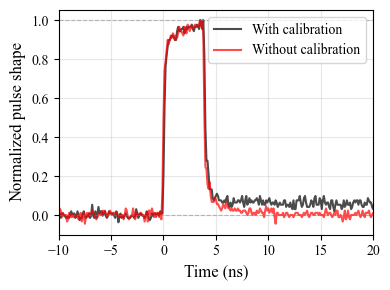

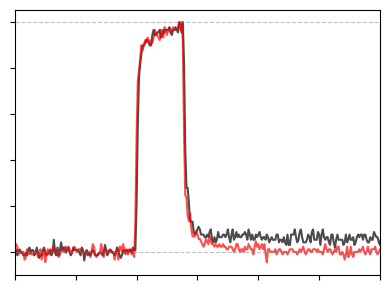

In [317]:
# without amplifier
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 파일 경로
filenames = [
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_123747_ch2.csv',
    r'C:\\Users\\oprs1\\Desktop\\JP\\1Project\\journal\\260205_123903_ch2.csv'
]

plt.figure(figsize=(4, 3))

# 각 파일을 읽어서 그래프에 추가
color = ['black', 'red']
for i, filename in enumerate(filenames, 1):
    df = pd.read_csv(filename, header=None)
    
    # 첫 번째 파일에서만 CSV 구조 확인
    if i == 1:
        print(f"CSV 파일의 열 개수: {len(df.columns)}")
        print(f"처음 5줄:\n{df.head()}")
    
    # 4번째 열(D열)을 x축, 5번째 열(E열)을 y축으로 사용
    x_data = df.iloc[:, 3]
    y_data = df.iloc[:, 4]
    print(y_data.max())
    # x축이 -0.5에서 -0.1 범위의 y값 평균 계산 (baseline)
    baseline_mask = (x_data >= -0.5e-7) & (x_data <= -0.1e-7)
    baseline_data = y_data[baseline_mask]
    
    if len(baseline_data) > 0:
        baseline_mean = baseline_data.mean()
        
        # 전체 데이터에서 baseline을 빼기 (0점 설정)
        y_corrected = y_data - baseline_mean
        
        # 최대값으로 정규화 (최대값을 1로 만들기)
        y_max = y_corrected.max()
        if y_max > 0:
            y_normalized = y_corrected / y_max
            
            plt.plot(x_data*1e9, y_normalized, color=color[i-1], linewidth=1.5, label=f'File {i}', alpha=0.7)
            print(f"File {i}: Baseline = {baseline_mean:.4f}, Max (after baseline) = {y_max:.4f}")
        else:
            print(f"File {i}: baseline 보정 후 최대값이 0 이하입니다.")
    else:
        print(f"File {i}: -0.5 ~ -0.1 범위에 데이터가 없습니다.")

plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('Normalized pulse shape', fontsize=12)
# plt.title('No terminate distortion ', fontsize=14)
plt.legend(['With calibration', 'Without calibration'], loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(-10, 20)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\pulse_no_amp_with_labels.svg', format='svg', bbox_inches='tight')
plt.show()

# 라벨 없는 버전
plt.figure(figsize=(4, 3))
for i, filename in enumerate(filenames, 1):
    df = pd.read_csv(filename, header=None)
    x_data = df.iloc[:, 3]
    y_data = df.iloc[:, 4]
    baseline_mask = (x_data >= -0.5e-7) & (x_data <= -0.1e-7)
    baseline_data = y_data[baseline_mask]
    
    if len(baseline_data) > 0:
        baseline_mean = baseline_data.mean()
        y_corrected = y_data - baseline_mean
        y_max = y_corrected.max()
        if y_max > 0:
            y_normalized = y_corrected / y_max
            plt.plot(x_data*1e9, y_normalized, color=color[i-1], linewidth=1.5, alpha=0.7)

plt.tick_params(labelbottom=False, labelleft=False)
plt.xlim(-10, 20)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\pulse_no_amp_no_labels.svg', format='svg', bbox_inches='tight')
plt.show()

## Green, red Rabi

Red Rabi fit: constant=0.000610, amplitude=0.3425, omega=0.0665, phase=1.2490, y0=0.5943
Green Rabi fit: constant=0.000701, amplitude=0.1436, omega=0.0659, phase=1.2801, y0=0.8356


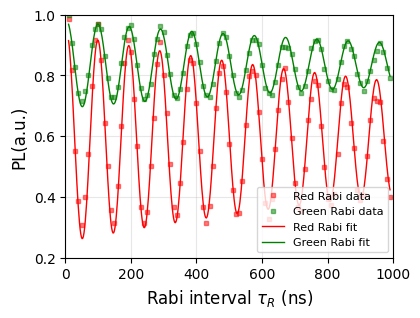

Red Rabi fit: constant=0.000610, amplitude=0.3425, omega=0.0665, phase=1.2490, y0=0.5943
Green Rabi fit: constant=0.000701, amplitude=0.1436, omega=0.0659, phase=1.2801, y0=0.8356


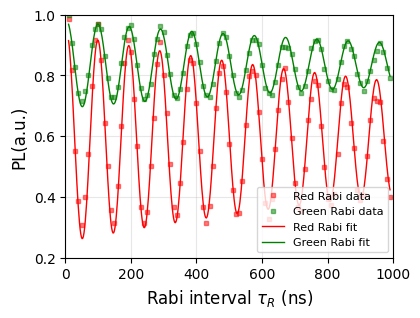

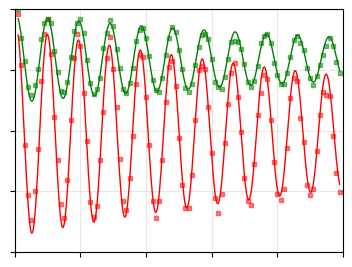

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 파일 경로
filenames = [
    r'C:\Users\oprs1\Measurement\rabi_gr_PSB\20260209\rabi_gr_PSB_08시36분55초.csv',
    r'C:\Users\oprs1\Measurement\rabi_gg_PSB\20260209\rabi_gg_PSB_13시32분21초.csv'
]

# 첫 번째 파일 읽기 (첫 줄 건너뛰기)
df1 = pd.read_csv(filenames[0], skiprows=1, header=None)
df2 = pd.read_csv(filenames[1], skiprows=1, header=None)

# 1열(0번 인덱스)을 x축, 6열(5번 인덱스)을 y축으로
x1 = df1.iloc[:, 0]
y1 = df1.iloc[:, 5]
x2 = df2.iloc[:, 0]
y2 = df2.iloc[:, 5]

# y 데이터 변환
y1_transformed = 1 - y1
y2_transformed = 1 - y2

# Damped sine 함수 정의
def damped_sine(x, constant, amplitude, omega, phase, y0):
    return np.exp(-constant * x) * amplitude * np.sin(omega * x + phase) + y0

# 데이터셋 1 (Red Rabi) 피팅
x1_arr = x1.to_numpy()
y1_arr = y1_transformed.to_numpy()
amplitude1_init = (y1_arr.max() - y1_arr.min()) / 2
constant1_init = 0.001
omega1_init = 2 * np.pi / 50
phase1_init = 0
y0_1_init = y1_arr.mean()
p0_1 = [constant1_init, amplitude1_init, omega1_init, phase1_init, y0_1_init]

x1_fit, y1_fit = None, None
try:
    popt1, _ = curve_fit(damped_sine, x1_arr, y1_arr, p0=p0_1, maxfev=10000)
    x1_fit = np.linspace(x1_arr.min(), x1_arr.max(), 500)
    y1_fit = damped_sine(x1_fit, *popt1)
    print(f"Red Rabi fit: constant={popt1[0]:.6f}, amplitude={popt1[1]:.4f}, omega={popt1[2]:.4f}, phase={popt1[3]:.4f}, y0={popt1[4]:.4f}")
except Exception as e:
    print(f"Red Rabi fitting failed: {e}")

# 데이터셋 2 (Green Rabi) 피팅
x2_arr = x2.to_numpy()
y2_arr = y2_transformed.to_numpy()
amplitude2_init = (y2_arr.max() - y2_arr.min()) / 2
constant2_init = 0.001
omega2_init = 2 * np.pi / 50
phase2_init = 0
y0_2_init = y2_arr.mean()
p0_2 = [constant2_init, amplitude2_init, omega2_init, phase2_init, y0_2_init]

x2_fit, y2_fit = None, None
try:
    popt2, _ = curve_fit(damped_sine, x2_arr, y2_arr, p0=p0_2, maxfev=10000)
    x2_fit = np.linspace(x2_arr.min(), x2_arr.max(), 500)
    y2_fit = damped_sine(x2_fit, *popt2)
    print(f"Green Rabi fit: constant={popt2[0]:.6f}, amplitude={popt2[1]:.4f}, omega={popt2[2]:.4f}, phase={popt2[3]:.4f}, y0={popt2[4]:.4f}")
except Exception as e:
    print(f"Green Rabi fitting failed: {e}")

# 요청값으로 y축 고정
y_min = 0.2
y_max = 1.0
common_yticks = [1.0, 0.8, 0.6, 0.4, 0.2]

# 두 버전 모두 동일한 figure 크기/여백 사용
left_margin, right_margin = 0.16, 0.98
bottom_margin, top_margin = 0.16, 0.97

# 라벨 있는 버전 (크기 통일)
fig, ax = plt.subplots(figsize=(4, 3))
fig.subplots_adjust(left=left_margin, right=right_margin, bottom=bottom_margin, top=top_margin)

ax.plot(x1, y1_transformed, marker='s', markersize=3, linewidth=0, color='red', alpha=0.5, label='Red Rabi data')
ax.plot(x2, y2_transformed, marker='s', markersize=3, linewidth=0, color='green', alpha=0.5, label='Green Rabi data')

if x1_fit is not None:
    ax.plot(x1_fit, y1_fit, '-', color='red', linewidth=1, label='Red Rabi fit')
if x2_fit is not None:
    ax.plot(x2_fit, y2_fit, '-', color='green', linewidth=1, label='Green Rabi fit')

ax.set_xlabel('Rabi interval $\\tau_R$ (ns)', fontsize=12)
ax.set_ylabel('PL(a.u.)', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1000)
ax.set_ylim(y_min, y_max)
ax.set_yticks(common_yticks)
fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\rabi_with_labels.svg', format='svg')
plt.show()

# 라벨 없는 버전 (크기 통일)
fig, ax = plt.subplots(figsize=(4, 3))
fig.subplots_adjust(left=left_margin, right=right_margin, bottom=bottom_margin, top=top_margin)

ax.plot(x1, y1_transformed, marker='s', markersize=3, linewidth=0, color='red', alpha=0.5)
ax.plot(x2, y2_transformed, marker='s', markersize=3, linewidth=0, color='green', alpha=0.5)

if x1_fit is not None:
    ax.plot(x1_fit, y1_fit, '-', color='red', linewidth=1)
if x2_fit is not None:
    ax.plot(x2_fit, y2_fit, '-', color='green', linewidth=1)

ax.set_xlim(0, 1000)
ax.set_ylim(y_min, y_max)
ax.set_yticks(common_yticks)
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False, labelleft=False)
fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\rabi_no_labels.svg', format='svg')
plt.show()

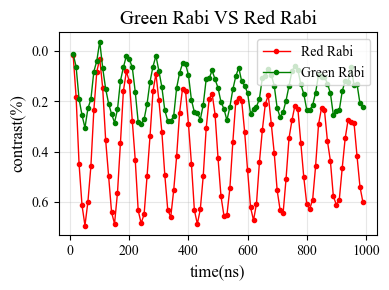

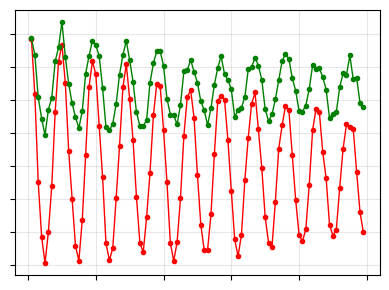

In [165]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# 파일 경로
filenames = [
    r'C:\\Users\\oprs1\\Measurement\\rabi_gr_PSB\\20260209\\rabi_gr_PSB_08시36분55초.csv',
    r'C:\\Users\\oprs1\\Measurement\\rabi_gg_PSB\\20260209\\rabi_gg_PSB_08시15분09초.csv'
]

# 첫 번째 파일 읽기 (첫 줄 건너뛰기)
df1 = pd.read_csv(filenames[0], skiprows=1, header=None)
df2 = pd.read_csv(filenames[1], skiprows=1, header=None)

# 1열(0번 인덱스)을 x축, 6열(5번 인덱스)을 y축으로
x1 = df1.iloc[:, 0]
y1 = df1.iloc[:, 5]
x2 = df2.iloc[:, 0]
y2 = df2.iloc[:, 5]

# 라벨 있는 버전
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x1, y1, marker='o', markersize=3, linewidth=1, color='red')
ax.plot(x2, y2, marker='o', markersize=3, linewidth=1, color='green')
ax.set_xlabel('time(ns)', fontsize=12)
ax.set_ylabel('contrast(%)', fontsize=12)
ax.set_title('Green Rabi VS Red Rabi', fontsize=14)
ax.legend(['Red Rabi', 'Green Rabi'], loc='upper right')
ax.invert_yaxis()  # y축 반전 (0이 위, 큰 값이 아래)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\rabi_raw_with_labels.svg', format='svg')
plt.show()

# 라벨 없는 버전
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(x1, y1, marker='o', markersize=3, linewidth=1, color='red')
ax.plot(x2, y2, marker='o', markersize=3, linewidth=1, color='green')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False, labelleft=False)
fig.tight_layout()
fig.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\rabi_raw_no_labels.svg', format='svg')
plt.show()

Rabi frequency = 0.005140 (1/ns)
π time = 97.27 ns
Decay T = 797.81 ns


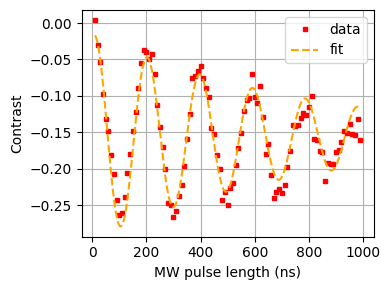

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# Load data
# =========================
file_path = r"C:\Users\oprs1\Measurement\rabi_gg_PSB\20260423\rabi_gg_PSB_14시34분17초.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

x = pd.to_numeric(df.iloc[:, 0], errors='coerce').to_numpy()
y = pd.to_numeric(df["apd_contrast"], errors='coerce').to_numpy()

valid = ~np.isnan(x) & ~np.isnan(y)
x = x[valid]
y = y[valid]

# =========================
# Rabi with decay
# =========================
def rabi_decay(x, A, f, phi, T, C):
    return A * np.cos(2*np.pi*f*x + phi) * np.exp(-x/T) + C

# =========================
# Initial guess
# =========================
A0 = (np.max(y) - np.min(y)) / 2
f0 = 1/200          # 대략 pi ~200ns 가정
phi0 = 0
T0 = (max(x) - min(x)) / 2
C0 = np.mean(y)

p0 = [A0, f0, phi0, T0, C0]

# =========================
# Fit
# =========================
popt, pcov = curve_fit(
    rabi_decay,
    x, y,
    p0=p0,
    maxfev=20000
)

A, f, phi, T, C = popt

# =========================
# 결과
# =========================
pi_time = 1 / (2*f)

print(f"Rabi frequency = {f:.6f} (1/ns)")
print(f"π time = {pi_time:.2f} ns")
print(f"Decay T = {T:.2f} ns")

# =========================
# Plot
# =========================
x_fit = np.linspace(min(x), max(x), 1000)
y_fit = rabi_decay(x_fit, *popt)

plt.figure(figsize=(4,3))
plt.plot(x, y, 's', markersize=3, label='data', color='red')
plt.plot(x_fit, y_fit, '--', label='fit', color='orange')

plt.xlabel("MW pulse length (ns)")
plt.ylabel("Contrast")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

컬럼 이름: ['Unnamed: 0', 'i_apd0', 'i_apd1', 'i_apd0_sum', 'i_apd1_sum', 'apd_contrast']


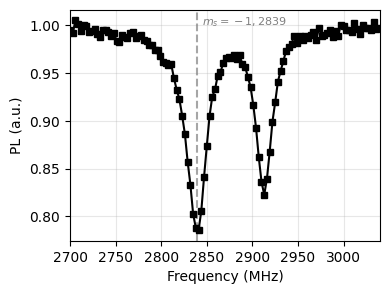

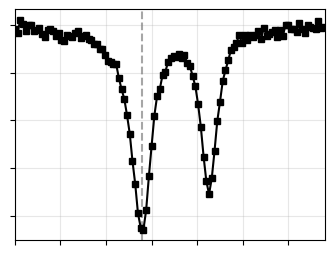

In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CSV 파일 읽기 (헤더 건너뛰기)
# filename = r'C:\Users\oprs1\Measurement\ODMR\20260209\ODMR_13시05분55초.csv'
filename = r'C:\Users\oprs1\Measurement\ODMR\20250207\ODMR_14시26분42초.csv'
df = pd.read_csv(filename, skiprows=1, header=None)

# 1열(0번 인덱스)을 x축으로 사용
x = df.iloc[:, 0]

# apd_contrast 열 찾기 (헤더를 읽어서 확인)
df_header = pd.read_csv(filename, nrows=0)
column_names = df_header.columns.tolist()
print("컬럼 이름:", column_names)

# apd_contrast 열의 인덱스 찾기
if 'apd_contrast' in column_names:
    contrast_idx = column_names.index('apd_contrast')
    # y = df.iloc[:, contrast_idx]
    # y = 1 + np.array(y)
    y = 1-(df.iloc[:, column_names.index('i_apd1_sum')] - df.iloc[:, column_names.index('i_apd0_sum')]) / df.iloc[:, column_names.index('i_apd1_sum')]
    
    # 그래프 그리기 (라벨 있는 버전)
    plt.figure(figsize=(4, 3))
    plt.axvline(x=2839, color='grey', linestyle='--', alpha = 0.7)
    plt.plot(x, y, 's', markersize=5, color='black', alpha=1)
    plt.plot(x, y, '-', markersize=5, color='black', alpha=1)
    plt.text(2845, 1, '$m_s = -1, 2839$', color='grey', fontsize=8)
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('PL (a.u.)')
    plt.xlim(2700, 3040)
    plt.grid(True, alpha=0.3)
    plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\odmr_with_labels.svg', format='svg', bbox_inches='tight')
    plt.show()
    
    # 그래프 그리기 (라벨 없는 버전)
    plt.figure(figsize=(4, 3))
    plt.axvline(x=2839, color='grey', linestyle='--', alpha = 0.7)
    plt.plot(x, y, 's', markersize=5, color='black', alpha=1)
    plt.plot(x, y, '-', markersize=5, color='black', alpha=1)
    plt.tick_params(labelbottom=False, labelleft=False)
    plt.xlim(2700, 3040)
    plt.grid(True, alpha=0.3)
    plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\odmr_no_labels.svg', format='svg', bbox_inches='tight')
    plt.show()
else:
    print("apd_contrast 열을 찾을 수 없습니다.")
    print("사용 가능한 컬럼:", column_names)

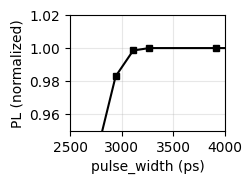

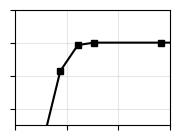

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CSV 파일 읽기 (헤더 건너뛰기)
# filename = r'C:\Users\oprs1\Measurement\rabi_gg_PSB\20260209\rabi_gg_PSB_13시32분21초.csv'
# df = pd.read_csv(filename, skiprows=1, header=None)

pulse_width = [350, 410, 670, 835, 1000, 1330, 2612, 2940, 3110, 3266, 3916, 5210, 7800, 10412, 20823]
count = [0, 0, 0, 1266, 3518, 8295, 12330, 13479, 13694, 13714, 13714, 13714, 13714, 13714, 13714]
count = np.array(count) / 13714  # 정규화

# 1열(0번 인덱스)을 x축으로 사용

# apd_contrast 열 찾기 (헤더를 읽어서 확인)
# df_header = pd.read_csv(filename, nrows=0)
# column_names = df_header.columns.tolist()
# print("컬럼 이름:", column_names)

# apd_contrast 열의 인덱스 찾기
# if 'apd_contrast' in column_names:
#     contrast_idx = column_names.index('apd_contrast')
#     y = df.iloc[:, contrast_idx]
#     y = 1 - np.array(y)
    
    # 그래프 그리기 (라벨 있는 버전)
plt.figure(figsize=(2, 1.5))
plt.plot(pulse_width, count, 's', markersize=5, color='black')
plt.plot(pulse_width, count, '-', markersize=5, color='black')
plt.xlabel('pulse_width (ps)')
plt.xlim(2500, 4000)
plt.ylim(0.95, 1.02)
plt.ylabel('PL (normalized)')
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\oprs1\Desktop\JP\4Archive\journal\gain_count.svg', format='svg', bbox_inches='tight')
plt.show()

# 그래프 그리기 (라벨 없는 버전)
plt.figure(figsize=(2 , 1.5))
plt.plot(pulse_width, count, 's', markersize=5, color='black')
plt.plot(pulse_width, count, '-', markersize=5, color='black')
plt.xlim(2500, 4000)
plt.ylim(0.95, 1.02)
plt.tick_params(labelbottom=False, labelleft=False)
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\oprs1\Desktop\JP\4Archive\journal\gain_count_no_labels.svg', format='svg', bbox_inches='tight')
plt.show()

Fitted parameters:
y0 = -0.002171
A = 0.221172
T = 465.151088 μs
p = 2.683102


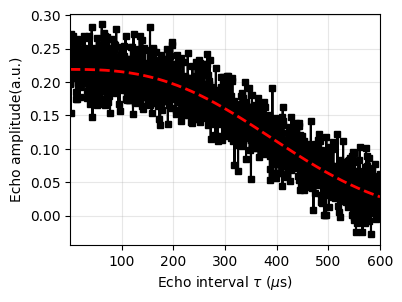

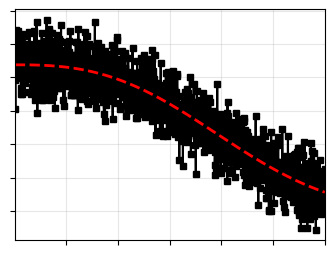

In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# CSV 파일 읽기
filename = r'C:\Users\oprs1\Desktop\JP\1Project\journal\XY16_10시49분08초.csv'
df = pd.read_csv(filename, skiprows=1, header=None)

# 1열(0번 인덱스)을 x축, 6열(5번 인덱스)을 y축으로
x = df.iloc[:, 0]/1000
# y = -df.iloc[:, 5]
y = (df.iloc[:, 4] - df.iloc[:, 3]) / (df.iloc[:, 4] + df.iloc[:, 3])

# Stretched exponential 함수 정의: y0 + A*exp(-(x/T)^p)
def stretched_exp(x, y0, A, T, p):
    return y0 + A * np.exp(-(x/T)**p)

# 초기 파라미터 추정
y0_init = y.min()
A_init = y.max() - y.min()
T_init = x.max() / 2
p_init = 1.0

# 데이터를 numpy 배열로 변환
x_arr = x.to_numpy()
y_arr = y.to_numpy()

# Curve fitting
try:
    popt, pcov = curve_fit(stretched_exp, x_arr, y_arr, 
                           p0=[y0_init, A_init, T_init, p_init], 
                           maxfev=10000)
    
    # 피팅된 파라미터
    y0_fit, A_fit, T_fit, p_fit = popt
    print(f"Fitted parameters:")
    print(f"y0 = {y0_fit:.6f}")
    print(f"A = {A_fit:.6f}")
    print(f"T = {T_fit:.6f} μs")
    print(f"p = {p_fit:.6f}")
    
    # 피팅 곡선 생성
    x_fit = np.linspace(x_arr.min(), x_arr.max(), 500)
    y_fit = stretched_exp(x_fit, *popt)
    
    # 그래프 그리기 (라벨 있는 버전)
    plt.figure(figsize=(4, 3))
    plt.plot(x, y, 's', markersize=5, color='black')
    plt.plot(x, y, '-', markersize=5, color='black')
    plt.plot(x_fit, y_fit, '--', color='red', linewidth=2)
    plt.xlabel('Echo interval $\\tau$ ($\\mu$s)')
    plt.ylabel('Echo amplitude(a.u.)')
    plt.xlim(x.min(), x.max())  # x축 범위 제한
    plt.grid(True, alpha=0.3)
    plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\Echo_with_labels.svg', format='svg', bbox_inches='tight')
    plt.show()
    
    # 그래프 그리기 (라벨 없는 버전)
    plt.figure(figsize=(4, 3))
    plt.plot(x, y, 's', markersize=5, color='black')
    plt.plot(x, y, '-', markersize=5, color='black')
    plt.plot(x_fit, y_fit, '--', color='red', linewidth=2)
    plt.xlim(x.min(), x.max())  # x축 범위 제한
    plt.tick_params(labelbottom=False, labelleft=False)
    plt.grid(True, alpha=0.3)
    plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\Echo_no_labels.svg', format='svg', bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"Fitting failed: {e}")
    # 피팅 실패 시 원본 그래프만 표시
    plt.figure(figsize=(4, 3))
    plt.plot(x, y, 'o-', markersize=4, color='blue')
    plt.xlabel('Echo interval $\\tau$ ($\\mu$s)')
    plt.ylabel('Normalized PL(a.u.)')
    plt.title('XY16 Data')
    # plt.grid(True, alpha=0.3)

    plt.show()    

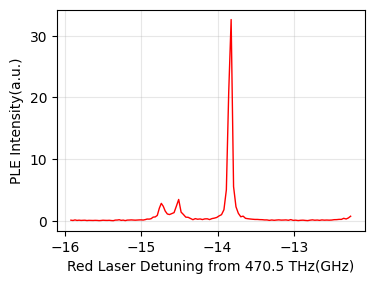

ValueError: x and y must have same first dimension, but have shapes (126,) and (643,)

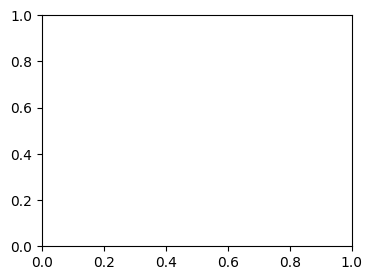

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 폴더 경로와 파일 목록
folder_path = r'C:\Users\oprs1\Measurement\PLE\20260429'
filenames = [
    'PLE_11시43분07초.csv',
]

# 한 개의 플롯 생성
plt.figure(figsize=(4, 3))

# 각 파일에 대해 그래프 그리기
offset = 0

# 광속 (nm·THz 단위)
c_nm_THz = 299792.458

for i, filename in enumerate(filenames):
    filepath = f"{folder_path}\\{filename}"
    
    # 데이터 읽기 (헤더 건너뛰기)
    df = pd.read_csv(filepath, skiprows=1, header=None)
    
    # x축: 2열(인덱스 1) - 파장(nm), y축: 3열(인덱스 2)
    wavelength_nm = df.iloc[:, 1]
    y = df.iloc[:, 2]
    
    # 파장을 주파수(THz)로 변환
    freq_THz = c_nm_THz / wavelength_nm
    
    # 470.5 THz로부터의 detuning 계산 (GHz 단위)
    detuning_GHz = (freq_THz - 470.5) * 1000
    
    # 로그 취하기
    # y_log = y
    
    # 정규화 (0~1 범위로)
    # y_normalized = (y_log - y_log.min()) / (y_log.max() - y_log.min())

# 특정 파장들에 대해 수직선 그리기
# reference_wavelengths = [637.196852, 637.19753, 637.199885, 637.20042, 637.201121]
# for wl in reference_wavelengths:
#     freq = c_nm_THz / wl
#     detuning = (freq - 470.5) * 1000
#     plt.axvline(x=detuning, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# plt.tick_params(labelleft=False)  # y축 눈금 라벨 제거
plt.xlabel('Red Laser Detuning from 470.5 THz(GHz)')
plt.ylabel('PLE Intensity(a.u.)')
# plt.tick_params(labelleft=False)  # y축 눈금 라벨 제거
# plt.legend(legend, loc='upper right', fontsize=8)
# plt.xlim(-17, -13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\ple_with_labels.svg', format='svg', bbox_inches='tight')
plt.plot(detuning_GHz, y, '-', color = 'red', linewidth=1)
plt.show()

# 라벨 없는 버전
plt.figure(figsize=(4, 3))
for i, filename in enumerate(filenames):
    filepath = f"{folder_path}\\{filename}"
    df = pd.read_csv(filepath, skiprows=1, header=None)
    wavelength_nm = df.iloc[:, 1]
    detuning_GHz = (freq_THz - 470.5) * 1000
    # y_normalized = (y_log - y_log.min()) / (y_log.max() - y_log.min())
    
    # -17부터 -13까지의 범위 필터링
    # mask = (detuning_GHz >= -17) & (detuning_GHz <= -13)
    
    plt.plot(detuning_GHz, y_normalized, '.', linewidth=1)

# for wl in reference_wavelengths:
#     freq = c_nm_THz / wl

plt.tick_params(labelbottom=False, labelleft=False)
plt.grid(alpha=0.3)
plt.xlim()
plt.tight_layout()
plt.savefig(r'C:\Users\oprs1\Desktop\JP\1Project\journal\ple_no_labels.svg', format='svg', bbox_inches='tight')
plt.show()

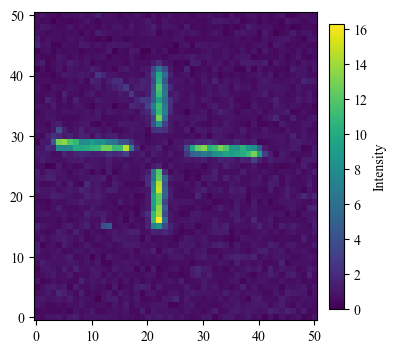

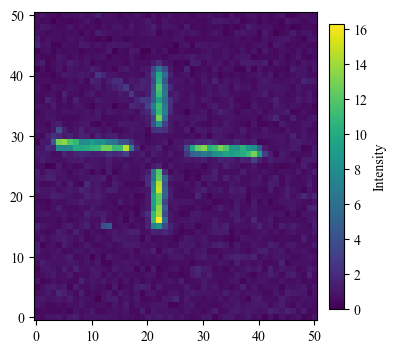

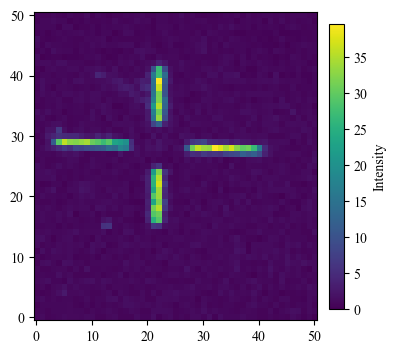

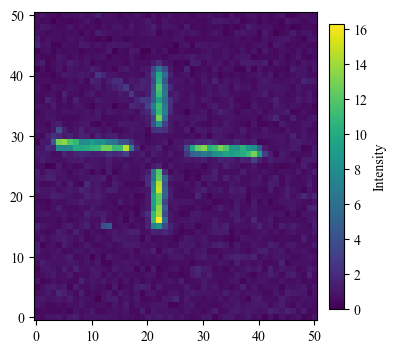

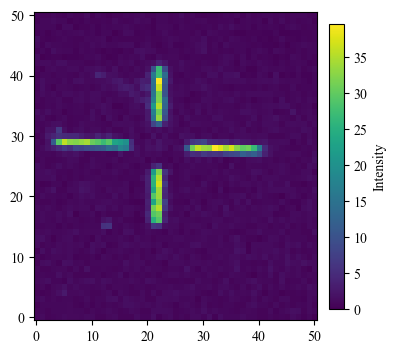

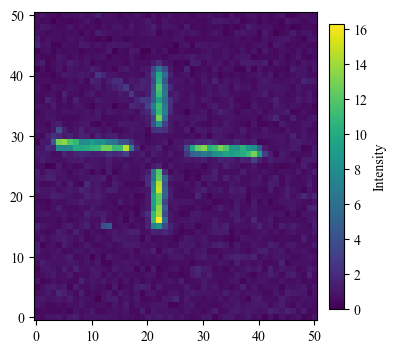

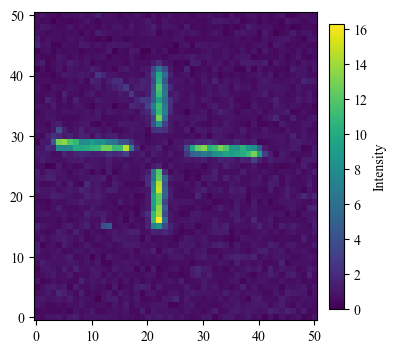

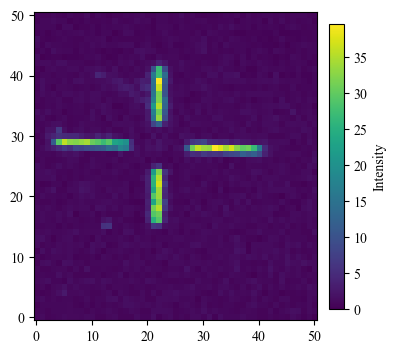

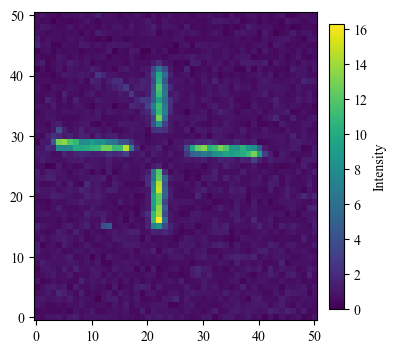

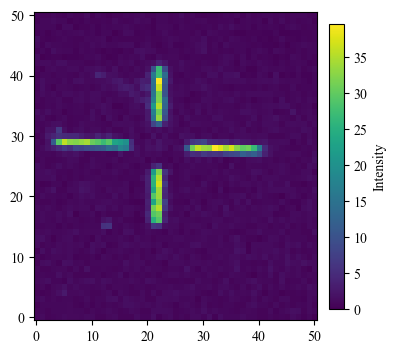

In [178]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 파일 경로
folder_path = r'C:\Users\oprs1\Measurement\Confocal\20260209'
filenames = [
    '11시02분46초, z=57.0000765.csv',
    '11시09분09초, z=57.0000765.csv'
]

# 저장 경로 및 파일명 (요청한 이름 그대로 저장)
save_paths = [
    r'C:\Users\oprs1\Desktop\JP\1Project\journal\wihtout auto-algin.svg',
    r'C:\Users\oprs1\Desktop\JP\1Project\journal\with auto-align.svg'
]

# 각 그림을 따로 그려서 저장
for filename, save_path in zip(filenames, save_paths):
    filepath = f"{folder_path}\\{filename}"

    # CSV 파일 읽기
    data = pd.read_csv(filepath, header=None)

    # 독립 figure 생성 (전체 4x4 유지 + 컬러바 포함)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(data, cmap='viridis', aspect='auto', origin='lower')
    fig.colorbar(im, ax=ax, label='Intensity', fraction=0.046, pad=0.04)
    fig.savefig(save_path, format='svg')
    plt.show()

for filename, save_path in zip(filenames, save_paths):
    filepath = f"{folder_path}\\{filename}"

    # CSV 파일 읽기
    data = pd.read_csv(filepath, header=None)

    # 독립 figure 생성 (전체 4x4 유지 + 컬러바 포함)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(data, cmap='viridis', aspect='auto', origin='lower')tick_params(labelleft=False)
    fig.colorbar(im, ax=ax, label='Intensity', fraction=0.046, pad=0.04)
    fig.savefig(save_path, format='svg')
    plt.show()

Amplitude = 0.239901
Omega = 0.0349978
Phase = 0.188965
Offset = 0.539531
Period = 179.531


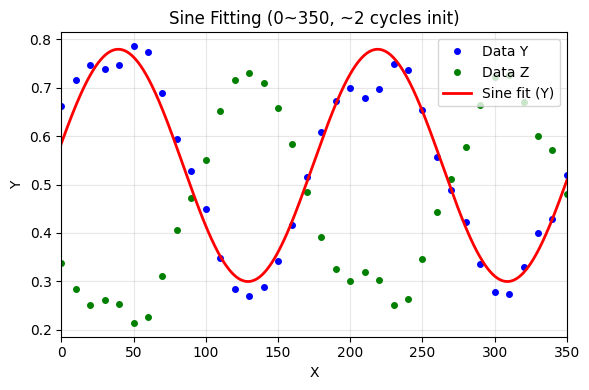

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

filepath = r'C:\Users\oprs1\Desktop\JP\다른사람\정진욱\260325_power_raw data.csv'
data = pd.read_csv(filepath, header=None)

# x: 1열, y: 4열, z: 5열 (첫 행 제외)
x_raw = pd.to_numeric(data.iloc[1:, 0], errors='coerce').to_numpy(dtype=float)
y_raw = pd.to_numeric(data.iloc[1:, 3], errors='coerce').to_numpy(dtype=float)
z_raw = pd.to_numeric(data.iloc[1:, 4], errors='coerce').to_numpy(dtype=float)

# 유효값 + x축 범위 제한 (0 ~ 350)
valid = np.isfinite(x_raw) & np.isfinite(y_raw) & np.isfinite(z_raw)
x = x_raw[valid]
y = y_raw[valid]
z = z_raw[valid]
range_mask = (x >= 0) & (x <= 350)
x = x[range_mask]
y = y[range_mask]
z = z[range_mask]

if x.size < 6:
    raise ValueError('0~350 구간에 유효 데이터가 너무 적어 피팅이 어렵습니다.')

# 피팅 안정성을 위해 x 정렬
sort_idx = np.argsort(x)
x = x[sort_idx]
y = y[sort_idx]
z = z[sort_idx]

# 사인 함수 모델
def sine_model(x, amplitude, omega, phase, offset):
    return amplitude * np.sin(omega * x + phase) + offset

# 초기값: 0~350에서 약 2사이클
amplitude0 = (y.max() - y.min()) / 2
offset0 = y.mean()
omega0 = 4 * np.pi / 350  # 약 2 cycles in [0, 350]
phase0 = 0.0
p0 = [amplitude0, omega0, phase0, offset0]

# 피팅 (omega를 양수로 제한)
lower_bounds = [0.0, 0.0, -2 * np.pi, y.min() - 0.5]
upper_bounds = [2.0, 1.0, 2 * np.pi, y.max() + 0.5]
popt, _ = curve_fit(sine_model, x, y, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=30000)
amplitude_fit, omega_fit, phase_fit, offset_fit = popt

# 피팅 곡선
x_fit = np.linspace(0, 350, 1000)
y_fit = sine_model(x_fit, *popt)

# 결과 출력
period_fit = (2 * np.pi / omega_fit) if omega_fit != 0 else np.inf
print(f'Amplitude = {amplitude_fit:.6g}')
print(f'Omega = {omega_fit:.6g}')
print(f'Phase = {phase_fit:.6g}')
print(f'Offset = {offset_fit:.6g}')
print(f'Period = {period_fit:.6g}')

# 그래프
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'o', markersize=4, color='blue', label='Data Y')
plt.plot(x, z, 'o', markersize=4, color='green', label='Data Z')
plt.plot(x_fit, y_fit, '-', color='red', linewidth=2, label='Sine fit (Y)')
plt.xlim(0, 350)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Sine Fitting (0~350, ~2 cycles init)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

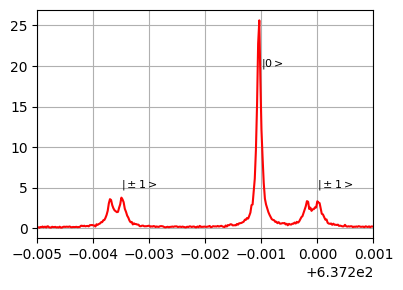

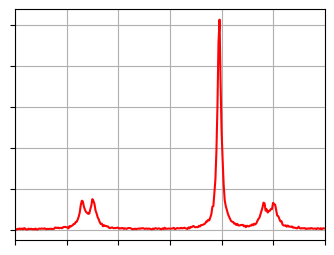

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

folder_path = r'C:\Users\oprs1\Measurement\\20260318'
filenames = ['PLE_11시38분51초.csv']

plt.figure(figsize=(4, 3))

filepath = f"{folder_path}\\{filenames[0]}"
df = pd.read_csv(filepath, skiprows=1, header=None)
wavelength_nm = df.iloc[:, 1]
wavelength_nm = wavelength_nm[wavelength_nm.between(637.19, 637.201)]
y = df.iloc[:, 2]
y = y[wavelength_nm.index]

plt.plot(wavelength_nm, y, '-', markersize=3, color='#FC0405')
plt.grid()
plt.tight_layout()
plt.xlim(637.195, 637.201)
plt.text(637.199, 20, '$|0>$', color='black', fontsize=8)
plt.text(637.1965, 5, '$|\pm1>$', color='black', fontsize=8)
plt.text(637.2, 5, '$|\pm1>$', color='black', fontsize=8)
plt.savefig(
    r'C:\Users\oprs1\Desktop\JP\1Project\journal\ple_final_style.svg',
    format='svg',
    bbox_inches='tight',
    pad_inches=0
)
plt.show()
plt.figure(figsize=(4, 3))
plt.plot(wavelength_nm, y, '-', markersize=3, color='#FC0405')
plt.grid()
plt.xlim(637.195, 637.201)
plt.tick_params(labelbottom=False, labelleft=False)
plt.savefig(
    r'C:\Users\oprs1\Desktop\JP\1Project\journal\ple_nolabel_final_style.svg',
    format='svg',
    bbox_inches='tight',
    pad_inches=0
)
plt.show()

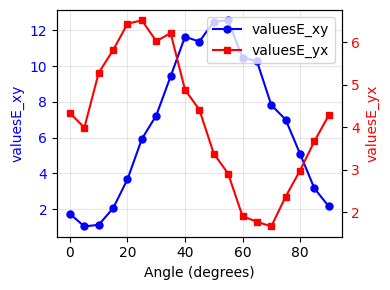

In [111]:
import matplotlib.pyplot as plt

angle = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]
valuesE_xy = [1.73, 1.03, 1.12, 2.05, 3.67, 5.93, 7.24, 9.43, 11.65, 11.38, 12.49, 12.57, 10.47, 10.29, 7.83, 7.01, 5.1, 3.16, 2.15]
valuesE_yx = [4.33, 3.99, 5.28, 5.81, 6.43, 6.51, 6.02, 6.21, 4.88, 4.41, 3.38, 2.91, 1.91, 1.78, 1.67, 2.37, 2.98, 3.67, 4.28]

fig, ax1 = plt.subplots(figsize=(4, 3))
ax2 = ax1.twinx()

line1 = ax1.plot(angle, valuesE_xy, 'o-', color='blue', markersize=5, label='valuesE_xy')
line2 = ax2.plot(angle, valuesE_yx, 's-', color='red', markersize=5, label='valuesE_yx')

ax1.set_xlabel('Angle (degrees)')
ax1.set_ylabel('valuesE_xy', color='blue')
ax2.set_ylabel('valuesE_yx', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')
ax1.grid(True, alpha=0.3)

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

1.0


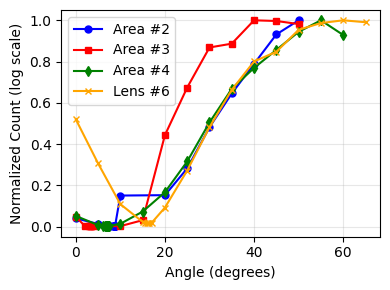

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None)
x1 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 0])
y1 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 1])
y1 = np.where(np.isnan(y1), 0, y1)  # None 값을 NaN으로 변환
y1 = y1/np.max(y1)  # 정규
x2 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 2])
y2 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 3])
y2 = np.where(np.isnan(y2), 0, y2)  # None 값을 NaN으로 변환
y2 = y2/np.max(y2)  # 정규화
x3 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 4])
y3 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 5])
y3 = np.where(np.isnan(y3), 0, y3)  # None 값을 NaN으로 변환
y3 = y3/np.max(y3)  # 정규화
x4 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 6])
y4 = np.array(pd.read_csv(r'C:\Users\oprs1\Desktop\JP\3Resource\pol_count.csv', header=None).iloc[:, 7])
y4 = np.where(np.isnan(y4), 0, y4)  # None 값을 NaN으로 변환
y4 = y4/np.max(y4)  # 정규화
print(y1.max())


plt.figure(figsize=(4, 3))
plt.plot(x1, y1, 'o-', color='blue', markersize=5)
plt.plot(x2, y2, 's-', color='red', markersize=5)
plt.plot(x3, y3, 'd-', color='green', markersize=5)
plt.plot(x4, y4, 'x-', color='orange', markersize=5)
# plt.yscale('log')
plt.xlabel('Angle (degrees)')
plt.ylabel('Normalized Count (log scale)')
plt.legend(['Area #2', 'Area #3', 'Area #4', 'Lens #6'])
plt.grid(True, alpha=0.3)
plt.tight_layout()




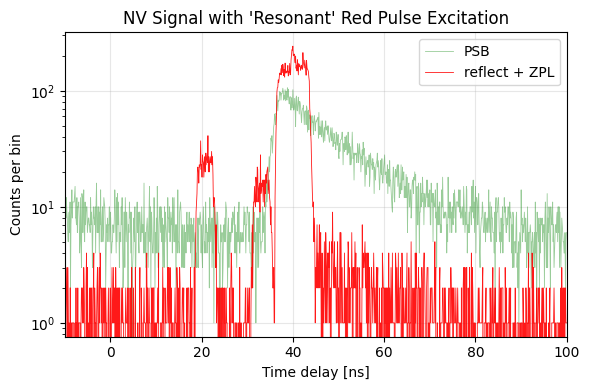

In [63]:
import numpy as np
import matplotlib.pyplot as plt

file_path_1 = r"C:\Users\oprs1\Measurement\Time Tagger\260519\PSB_resonant.txt"
data_1 = np.loadtxt(file_path_1, skiprows=1)
time_ps_1 = data_1[:, 0]
counts_1 = data_1[:, 1]
time_ns_1 = time_ps_1 / 1000

file_path_2 = r"C:\Users\oprs1\Measurement\Time Tagger\260519\ZPL_resonant.txt"
data_2 = np.loadtxt(file_path_2, skiprows=1)
time_ps_2 = data_2[:, 0]
counts_2 = data_2[:, 1]
time_ns_2 = time_ps_2 / 1000

# 원하는 시간 범위
mask1 = (time_ns_1 >= -10) & (time_ns_1 <= 100)
mask2 = (time_ns_2 >= -10) & (time_ns_2 <= 100)

plt.figure(figsize=(6,4))

plt.plot(time_ns_1[mask1], counts_1[mask1],
         linewidth=0.6,
         color='green',
         alpha=0.4,
         label='PSB')

plt.plot(time_ns_2[mask2], counts_2[mask2],
         linewidth=0.6,
         color='red',
         alpha=0.9,
         label='reflect + ZPL')

plt.xlabel("Time delay [ns]")
plt.ylabel("Counts per bin")

plt.yscale('log')

plt.xlim(-10, 100)

plt.title("NV Signal with 'Resonant' Red Pulse Excitation")

plt.grid(alpha=0.3)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

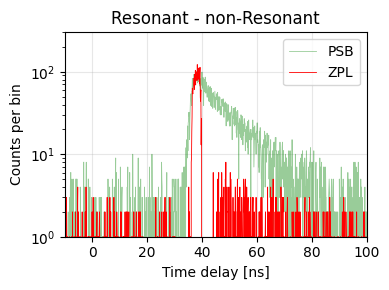

In [13]:
import numpy as np
import matplotlib.pyplot as plt

ZPL_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260519\ZPL_resonant.txt",
                   skiprows=1)

ZPL_non_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260519\ZPL_non_resonant.txt",
                   skiprows=1)

PSB_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260519\PSB_resonant.txt",
                   skiprows=1)

PSB_non_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260519\PSB_non_resonant.txt",
                   skiprows=1)


time_ns = ZPL_resonant[:,0] / 1000

ZPL_counts_resonant = ZPL_resonant[:,1]
ZPL_counts_non_resonant = ZPL_non_resonant[:,1]

PSB_counts_resonant = PSB_resonant[:,1]
PSB_counts_non_resonant = PSB_non_resonant[:,1]

pure_ZPL_signal = ZPL_counts_resonant - ZPL_counts_non_resonant
pure_PSB_signal = PSB_counts_resonant - PSB_counts_non_resonant

x_min, x_max = -10, 100
mask = (time_ns >= x_min) & (time_ns <= x_max)


plt.figure(figsize=(4,3))


plt.plot(time_ns[mask],
         pure_PSB_signal[mask],
         linewidth=0.6,
         color='green',
         label='PSB',
         alpha=0.4)

plt.plot(time_ns[mask],
         pure_ZPL_signal[mask],
         linewidth=0.6,
         color='red',
         label='ZPL',
         alpha=1)

plt.xlabel("Time delay [ns]")
plt.ylabel("Counts per bin")
plt.title("Resonant - non-Resonant")

plt.xlim(-10, 100)
plt.ylim(1, 300)

plt.yscale('log')

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

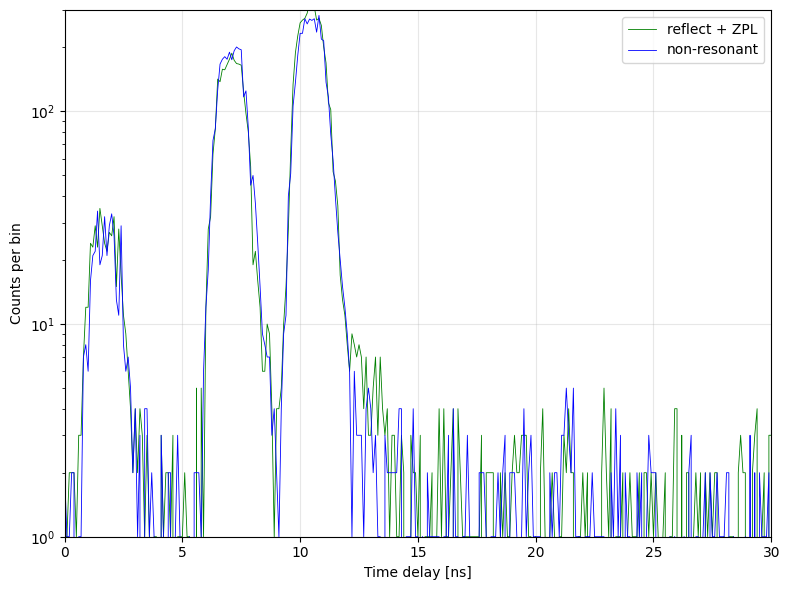

In [26]:
import numpy as np
import matplotlib.pyplot as plt

ZPL_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260518\resonant.txt",
                   skiprows=1)

ZPL_non_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260518\non_resonant.txt",
                   skiprows=1)


time_ns = ZPL_resonant[:,0] / 1000
time_ns = time_ns - 30

ZPL_counts_resonant = ZPL_resonant[:,1]
ZPL_counts_non_resonant = ZPL_non_resonant[:,1]

pure_ZPL_signal = ZPL_counts_resonant - ZPL_counts_non_resonant


x_min, x_max = -10, 100
mask = (time_ns >= x_min) & (time_ns <= x_max)


plt.figure(figsize=(8,6))

plt.plot(time_ns[mask],
         ZPL_counts_resonant[mask],
         linewidth=0.6,
         color='green',
         label='reflect + ZPL',
         alpha=1)

plt.plot(time_ns[mask],
         ZPL_counts_non_resonant[mask],
         linewidth=0.6,
         color='blue',
         label='non-resonant',
         alpha=1)

# plt.plot(time_ns[mask],
#          pure_ZPL_signal[mask],
#          linewidth=0.6,
#          color='tab:red',
#          label='ZPL',
#          alpha=0.8)

plt.xlabel("Time delay [ns]")
plt.ylabel("Counts per bin")
plt.title("")

plt.xlim(0, 30)
plt.ylim(1, 300)

plt.yscale('log')

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

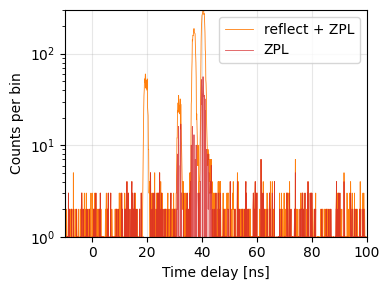

In [22]:
import numpy as np
import matplotlib.pyplot as plt

ZPL_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260518\resonant.txt",
                   skiprows=1)

ZPL_non_resonant = np.loadtxt(r"C:\Users\oprs1\Measurement\Time Tagger\260518\non_resonant.txt",
                   skiprows=1)


time_ns = ZPL_resonant[:,0] / 1000

ZPL_counts_resonant = ZPL_resonant[:,1]
ZPL_counts_non_resonant = ZPL_non_resonant[:,1]

pure_ZPL_signal = ZPL_counts_resonant - ZPL_counts_non_resonant


x_min, x_max = -10, 100
mask = (time_ns >= x_min) & (time_ns <= x_max)


plt.figure(figsize=(4,3))

plt.plot(time_ns[mask],
         ZPL_counts_resonant[mask],
         linewidth=0.6,
         color='tab:orange',
         label='reflect + ZPL',
         alpha=1)

plt.plot(time_ns[mask],
         pure_ZPL_signal[mask],
         linewidth=0.6,
         color='tab:red',
         label='ZPL',
         alpha=0.8)

plt.xlabel("Time delay [ns]")
plt.ylabel("Counts per bin")
plt.title("")

plt.xlim(-10, 100)
plt.ylim(1, 300)

plt.yscale('log')

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

src_dir = Path(r"C:\Users\oprs1\Measurement\Time Tagger\260609")

dst_dir = src_dir / "log_scaled_png"
dst_dir.mkdir(parents=True, exist_ok=True)

for txt_path in sorted(src_dir.glob("*.txt")):
    data = np.loadtxt(txt_path, skiprows=1)
    if data.ndim == 1:
        data = data.reshape(-1, data.shape[0])

    x = data[:, 0]
    x = x-18000  # 시간 오프셋 조정 (예시로 20000을 빼줌, 필요에 따라 조정)
    ys = data[:, 1:]
    # ys = np.maximum(ys, 1e-12)
    

    plt.figure(figsize=(10, 5))
    if ys.ndim == 1:
        plt.plot(x, ys, label=txt_path.stem)
    else:
        for col in range(ys.shape[1]):
            plt.plot(x, ys[:, col], label=f"col{col+2}")

    plt.xlabel("Time [original units]")
    plt.ylabel("log10(counts)")
    plt.title(txt_path.name)
    plt.grid(alpha=0.3)
    plt.yscale('log')
    if ys.ndim > 1:
        plt.legend(fontsize="small", loc="best")

    out_path = dst_dir / f"{txt_path.stem}_log.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()

    print(f"Saved {out_path}")

lin_dir = src_dir / "lin_scaled_png"
lin_dir.mkdir(parents=True, exist_ok=True)

for txt_path in sorted(src_dir.glob("*.txt")):
    data = np.loadtxt(txt_path, skiprows=1)
    if data.ndim == 1:
        data = data.reshape(-1, data.shape[0])

    x = data[:, 0]
    x = x-18000  # 시간 오프셋 조정 (예시로 20000을 빼줌, 필요에 따라 조정)
    ys = data[:, 1:]
    # ys = np.maximum(ys, 1e-12)
    

    plt.figure(figsize=(10, 5))
    if ys.ndim == 1:
        plt.plot(x, ys, label=txt_path.stem)
    else:
        for col in range(ys.shape[1]):
            plt.plot(x, ys[:, col], label=f"col{col+2}")

    plt.xlabel("Time difference(ns)")
    plt.ylabel("log10(counts)")
    plt.yscale('linear')
    plt.title(txt_path.name)
    plt.grid(alpha=0.3)
    if ys.ndim > 1:
        plt.legend(fontsize="small", loc="best")

    out_path = lin_dir / f"{txt_path.stem}.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()

    print(f"Saved {out_path}")

Saved C:\Users\oprs1\Measurement\Time Tagger\260609\log_scaled_png\2026-06-09_161407_PSB_log.png
Saved C:\Users\oprs1\Measurement\Time Tagger\260609\log_scaled_png\2026-06-09_161407_ZPL_log.png
Saved C:\Users\oprs1\Measurement\Time Tagger\260609\log_scaled_png\2026-06-09_170243_PSB_log.png
Saved C:\Users\oprs1\Measurement\Time Tagger\260609\log_scaled_png\2026-06-09_170243_ZPL_log.png
Saved C:\Users\oprs1\Measurement\Time Tagger\260609\lin_scaled_png\2026-06-09_161407_PSB.png
Saved C:\Users\oprs1\Measurement\Time Tagger\260609\lin_scaled_png\2026-06-09_161407_ZPL.png
Saved C:\Users\oprs1\Measurement\Time Tagger\260609\lin_scaled_png\2026-06-09_170243_PSB.png
Saved C:\Users\oprs1\Measurement\Time Tagger\260609\lin_scaled_png\2026-06-09_170243_ZPL.png


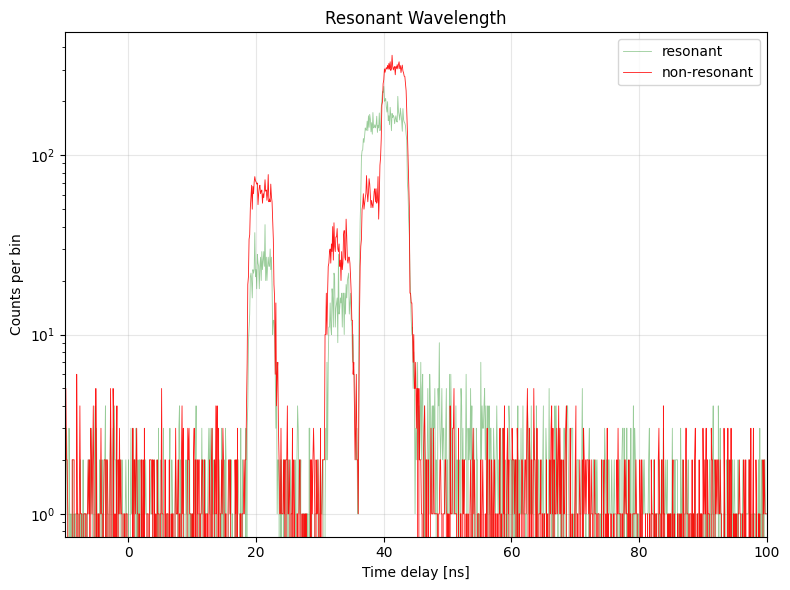

In [17]:
import numpy as np
import matplotlib.pyplot as plt

file_path_1 = r"C:\Users\oprs1\Measurement\Time Tagger\260519\ZPL_resonant.txt"
data_1 = np.loadtxt(file_path_1, skiprows=1)
time_ps_1 = data_1[:, 0]
counts_1 = data_1[:, 1]
time_ns_1 = time_ps_1 / 1000

file_path_2 = r"C:\Users\oprs1\Measurement\Time Tagger\260519\ZPL_non_resonant.txt"
data_2 = np.loadtxt(file_path_2, skiprows=1)
time_ps_2 = data_2[:, 0]
counts_2 = data_2[:, 1]
time_ns_2 = time_ps_2 / 1000

# 원하는 시간 범위
mask1 = (time_ns_1 >= -10) & (time_ns_1 <= 100)
mask2 = (time_ns_2 >= -10) & (time_ns_2 <= 100)

plt.figure(figsize=(8,6))

plt.plot(time_ns_1[mask1], counts_1[mask1],
         linewidth=0.6,
         color='green',
         alpha=0.4,
         label='resonant')

plt.plot(time_ns_2[mask2], counts_2[mask2],
         linewidth=0.6,
         color='red',
         alpha=0.9,
         label='non-resonant')

plt.xlabel("Time delay [ns]")
plt.ylabel("Counts per bin")

plt.yscale('log')

plt.xlim(-10, 100)

plt.title("Resonant Wavelength")

plt.grid(alpha=0.3)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [1]:
import numpy as np

# ===============================
# AWG Settings
# ===============================
sample_rate = 25e9        # 25 GS/s
waveform_time = 100e-6    # 100 us total waveform
pulse_freq = 10e6         # 10 MHz pulse repetition frequency

# Pulse width modulation
min_width = 5e-9          # 5 ns
max_width = 50e-9         # 50 ns
mod_freq = 100e3          # 100 kHz modulation frequency

# Output amplitude
high = 1.0
low = 0.0

# ===============================
# Generate waveform
# ===============================
num_samples = int(sample_rate * waveform_time)
waveform = np.zeros(num_samples)

period_samples = int(sample_rate / pulse_freq)

num_periods = num_samples // period_samples

for i in range(num_periods):

    # Time at the beginning of this pulse
    t = i / pulse_freq

    # Pulse width varies sinusoidally
    pulse_width = (min_width + max_width)/2 \
        + (max_width-min_width)/2 * np.sin(2*np.pi*mod_freq*t)

    width_samples = int(round(pulse_width * sample_rate))

    start = i * period_samples
    stop = min(start + width_samples, num_samples)

    waveform[start:stop] = high

# ===============================
# Save CSV
# ===============================
np.savetxt(
    "C:\\Users\\oprs1\\Desktop\\JP\\1Project\\pulse width\\PWM_waveform.csv",
    waveform,
    fmt="%.6f",
    delimiter=","
)

print("Waveform saved as PWM_waveform.csv")
print(f"Total samples: {num_samples}")

Waveform saved as PWM_waveform.csv
Total samples: 2500000


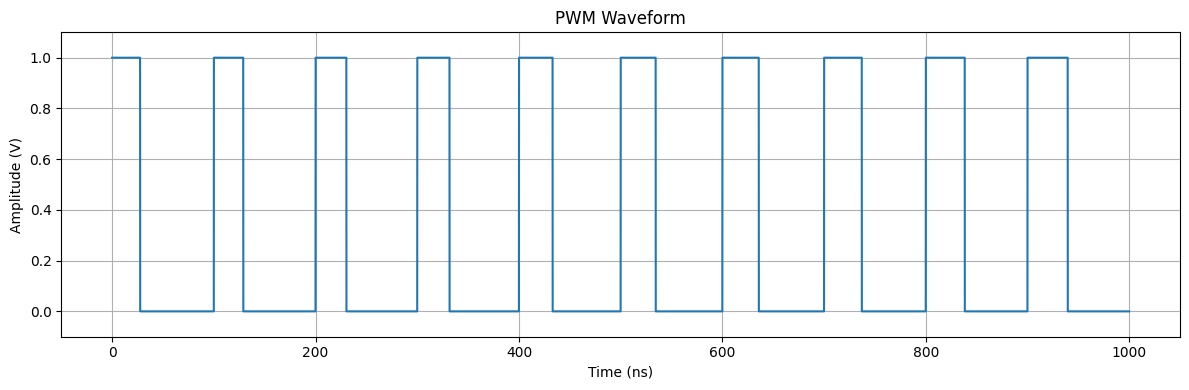

In [2]:
import matplotlib.pyplot as plt

# ===============================
# Plot waveform
# ===============================

# 처음 10개의 펄스만 보기
num_periods_to_plot = 10
samples_to_plot = num_periods_to_plot * period_samples

time = np.arange(samples_to_plot) / sample_rate * 1e9  # ns

plt.figure(figsize=(12,4))
plt.plot(time, waveform[:samples_to_plot], linewidth=1.5)
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (V)")
plt.title("PWM Waveform")
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()